# 01 — Bridge Fire Ingest, Part A: Reconnaissance

**What this notebook does:** everything up to and including the dNBR raster for the 2024 Bridge Fire
(San Gabriel Mountains, Los Angeles / San Bernardino Counties).

**This part (cells 1 to 3) is reconnaissance only.** It fetches a burn perimeter, works out which
Sentinel-2 tiles cover it, and scores candidate scenes for cloud. It downloads almost nothing.
The point is to produce numbers you can look at and sanity check *before* any expensive read runs.

Part B (the windowed band reads, the baseline offset, the dNBR computation and the write to Drive)
gets added to this same notebook once these three cells report something sensible.

Nothing here touches `src/debrisflow/`. This is pure network IO, which per the project's design
lives in the notebook, not in tested modules.

---
## Cell 1 — Environment and storage

Three things happen here.

**Install.** Colab already has `rasterio`, `geopandas` and `shapely`. It does not have
`pystac-client` (talks to STAC catalogues) or `planetary-computer` (signs Microsoft's asset URLs so
they can be read). Both are small and pure-Python, so this is quick.

**Mount Google Drive.** Colab's own filesystem is wiped when the runtime disconnects. Drive is a
folder that survives. When you run this cell a popup appears asking you to pick a Google account and
grant Colab access to Drive; approve it and `/content/drive/MyDrive/` becomes an ordinary directory
you can read and write with normal Python. Anything written there also shows up in Drive on the web.

You may be asked to re-approve in future sessions. That is normal and is the only manual step in
this notebook.

**Set paths.** Everything this project writes goes under one folder in Drive, so the outputs are
easy to find and easy to delete if a run goes wrong.

In [ ]:
# Cell 1 --- environment, Drive, paths

# %cd guards against the persistent-working-directory problem noted in the handoff.
%cd /content

!pip install -q pystac-client planetary-computer

import json
import os
from pathlib import Path

# --- Mount Google Drive -------------------------------------------------------
# A popup will ask for permission the first time you run this in a session.
from google.colab import drive
drive.mount('/content/drive')

# --- Project storage ----------------------------------------------------------
# One folder for everything this pipeline produces. Created if it does not exist.
DRIVE_ROOT = Path('/content/drive/MyDrive/postfire-debris-flow')
FIRE_NAME  = 'bridge_2024'
FIRE_DIR   = DRIVE_ROOT / FIRE_NAME
for d in (FIRE_DIR / 'perimeter', FIRE_DIR / 'severity', FIRE_DIR / 'terrain'):
    d.mkdir(parents=True, exist_ok=True)

print('Storage ready:')
for d in sorted(FIRE_DIR.rglob('*')):
    print('  ', d)

/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.8 MB/s eta 0:00:00
Mounted at /content/drive
Storage ready:
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/perimeter
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/perimeter/bridge_2024_perimeter.geojson
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/bridge_2024_dnbr_20m.tif
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/post_20240929_refl_20m.tif
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/post_20240929_scl_20m.tif
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/pre_20240820_refl_20m.tif
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/pre_20240820_scl_20m.tif
   /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/provenance_dnbr.jso

---
## Cell 2 — The burn perimeter

The perimeter is load-bearing twice over. It defines the window we read imagery for, and its
*complement* defines the unburned pixels used to offset-correct dNBR. So it has to come from a
published source, not a bounding box someone typed in.

**Source: CAL FIRE FRAP**, the California historic fire perimeter service. FRAP publishes after the
end of each calendar year, so it lags for a fire in the current season, but the 2024 season has been
published for a long time now and FRAP is the authoritative California record. NIFC's interagency
history layer is kept as a fallback: it is national in scope but noticeably thinner for recent years.

Both are ArcGIS FeatureServers, so an ordinary HTTPS GET with query parameters returns GeoJSON.
No account, no key, no SDK.

### Two filters, not one

The first version of this cell searched on name alone and returned 212 features, because "bridge"
appears in fire names constantly. So the query now applies **two independent constraints**:

- **Name** contains "bridge"
- **Location** intersects an envelope over the San Gabriel Mountains

The spatial filter is passed to the server as a `geometry` parameter, so the far-away matches are
never returned at all rather than being filtered out afterwards. This is the constraint that
actually does the work. A 1972 fire in Alaska named BRIDGE satisfies the name test perfectly.

The envelope is deliberately loose, roughly the eastern San Gabriels and their approaches. It only
has to be tight enough to exclude other states.

In [ ]:
# Cell 2 --- fetch the Bridge Fire perimeter (CAL FIRE FRAP primary, NIFC fallback)

import requests
import geopandas as gpd
from shapely.geometry import shape
from shapely.ops import unary_union

# Search envelope over the San Gabriel Mountains: xmin, ymin, xmax, ymax in WGS84.
# Loose on purpose. It exists to exclude other states, not to pre-empt the perimeter.
AOI_BOX = (-118.10, 34.05, -117.40, 34.55)
TARGET_YEAR = 2024

# (label, url, name field, year field, acres field)
CANDIDATE_SERVICES = [
    ('CAL FIRE FRAP, all perimeters',
     'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/'
     'California_Historic_Fire_Perimeters/FeatureServer/0/query',
     'FIRE_NAME', 'YEAR_', 'GIS_ACRES'),
    ('CAL FIRE FRAP, 1950+',
     'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/'
     'California_Historic_Fire_Perimeters/FeatureServer/2/query',
     'FIRE_NAME', 'YEAR_', 'GIS_ACRES'),
    ('NIFC interagency perimeter history',
     'https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/services/'
     'InterAgencyFirePerimeterHistory_All_Years_View/FeatureServer/0/query',
     'INCIDENT', 'FIRE_YEAR', 'GIS_ACRES'),
]


def query_service(url, where):
    # The geometry parameter makes the spatial filter server-side.
    params = {
        'where': where,
        'geometry': ','.join(str(v) for v in AOI_BOX),
        'geometryType': 'esriGeometryEnvelope',
        'inSR': '4326',
        'spatialRel': 'esriSpatialRelIntersects',
        'outFields': '*',
        'outSR': '4326',
        'f': 'geojson',
        'returnGeometry': 'true',
    }
    r = requests.get(url, params=params, timeout=90)
    r.raise_for_status()
    return r.json()


hits, used = None, None
for label, url, name_f, year_f, acres_f in CANDIDATE_SERVICES:
    # Try a name+year clause first, then name only, then everything in the box.
    clauses = [
        f"UPPER({name_f}) LIKE '%BRIDGE%' AND {year_f} = {TARGET_YEAR}",
        f"UPPER({name_f}) LIKE '%BRIDGE%' AND {year_f} = '{TARGET_YEAR}'",
        f"UPPER({name_f}) LIKE '%BRIDGE%'",
        '1=1',
    ]
    for where in clauses:
        try:
            gj = query_service(url, where)
        except Exception as e:
            print(f'[skip] {label:38s} | {where[:44]:44s} -> {type(e).__name__}')
            continue
        feats = gj.get('features', [])
        print(f'[try ] {label:38s} | {where[:44]:44s} -> {len(feats):4d} feature(s)')
        if feats:
            hits, used = gj, (label, where, name_f, year_f)
            break
    if hits:
        break

if not hits:
    raise RuntimeError('No perimeter returned from any service. Check the URLs in a browser.')

label, where, NAME_F, YEAR_F = used
gdf_all = gpd.GeoDataFrame.from_features(hits['features'], crs='EPSG:4326')
gdf_all['_acres'] = gdf_all.to_crs('EPSG:32611').area / 4046.86

print(f'\nMatched via : {label}')
print(f'Where clause: {where}')
print(f'Candidates  : {len(gdf_all)}\n')

cols = [c for c in (NAME_F, YEAR_F, 'ALARM_DATE', 'CONT_DATE') if c in gdf_all.columns]
preview = gdf_all[cols].copy()
preview['acres'] = gdf_all['_acres'].round(0)
print(preview.sort_values('acres', ascending=False).head(20).to_string())

[try ] CAL FIRE FRAP, all perimeters          | UPPER(FIRE_NAME) LIKE '%BRIDGE%' AND YEAR_ = ->    1 feature(s)

Matched via : CAL FIRE FRAP, all perimeters
Where clause: UPPER(FIRE_NAME) LIKE '%BRIDGE%' AND YEAR_ = 2024
Candidates  : 1

  FIRE_NAME  YEAR_     ALARM_DATE      CONT_DATE    acres
0    BRIDGE   2024  1725753600000  1735603200000  56281.0


### Selecting, with a guard that can fail

The previous version of this cell picked the largest candidate and saved it. That is how a fire in
Alaska ended up in the output, so selection is now explicit and checked.

Selection order: filter to the target year if a usable year field exists, then take the largest
remaining candidate. The spatial query has already removed everything outside California, so
"largest" is now a reasonable tiebreaker rather than a global sort.

**Then three assertions run before anything is written to Drive:**

1. The centroid falls inside the search envelope
2. The area is between 100 and 400 km², roughly bracketing the 55,000 acre published figure
3. The longitude is negative and in the −117 to −119 range, which is a blunt "are we in California"
   check that would have caught the Alaska result on its own

If any of these fail, the cell raises with a readable message and writes nothing. A hard failure
here costs you thirty seconds. A silent wrong perimeter costs you the whole pipeline downstream,
and it would look completely plausible the entire way.

**Dissolve.** Fire perimeters often arrive as multipart polygons with interior holes for unburned
islands. The holes are real and useful for the offset correction later, so we keep them and only
merge the rows into a single geometry.

In [ ]:
# Cell 2b --- select, verify, dissolve, save

# --- Selection ----------------------------------------------------------------
cand = gdf_all.copy()
if YEAR_F in cand.columns:
    yr = cand[YEAR_F].astype(str).str.extract(r'(\d{4})')[0]
    matched = cand[yr == str(TARGET_YEAR)]
    if len(matched):
        cand = matched
        print(f'Filtered to {YEAR_F} == {TARGET_YEAR}: {len(cand)} candidate(s)')
    else:
        print(f'WARNING: no candidate has {YEAR_F} == {TARGET_YEAR}. Using all in-box matches.')

sel = cand.sort_values('_acres', ascending=False).head(1)
perim = unary_union(sel.geometry.values)
perimeter = gpd.GeoDataFrame(geometry=[perim], crs='EPSG:4326')

perim_utm = perimeter.to_crs('EPSG:32611')
area_km2 = float(perim_utm.area.iloc[0]) / 1e6
acres = area_km2 * 247.105
cx, cy = perim.centroid.x, perim.centroid.y
minx, miny, maxx, maxy = perimeter.total_bounds

print('\n--- Selected ---')
for c in [c for c in (NAME_F, YEAR_F) if c in sel.columns]:
    print(f'{c:12s}: {sel.iloc[0][c]}')
print(f'Area        : {area_km2:,.1f} km^2  ({acres:,.0f} acres)')
print(f'Centroid    : {cx:.4f}, {cy:.4f}')
print(f'Bounds      : {minx:.4f}, {miny:.4f} -> {maxx:.4f}, {maxy:.4f}')

# --- Guards -------------------------------------------------------------------
# These exist because a wrong perimeter is not visually obvious downstream.
bx0, by0, bx1, by1 = AOI_BOX
problems = []
if not (bx0 <= cx <= bx1 and by0 <= cy <= by1):
    problems.append(f'centroid {cx:.3f},{cy:.3f} is outside the search envelope {AOI_BOX}')
if not (100 <= area_km2 <= 400):
    problems.append(f'area {area_km2:,.1f} km^2 is outside the expected 100-400 km^2 range')
if not (-119.0 <= cx <= -117.0):
    problems.append(f'longitude {cx:.3f} is not in southern California')
if problems:
    raise ValueError('Perimeter failed validation, nothing saved:\n  - ' + '\n  - '.join(problems))

print('\nGuards passed.')

# --- Geometry detail ----------------------------------------------------------
parts = list(perim.geoms) if perim.geom_type == 'MultiPolygon' else [perim]
print(f'Geometry    : {perim.geom_type}, {len(parts)} part(s), '
      f'{sum(len(p.interiors) for p in parts)} interior hole(s)')

# --- Save ---------------------------------------------------------------------
PERIM_PATH = FIRE_DIR / 'perimeter' / 'bridge_2024_perimeter.geojson'
perimeter.to_file(PERIM_PATH, driver='GeoJSON')
print(f'Saved       -> {PERIM_PATH}')

perimeter.explore(style_kwds={'color': '#ff6b35', 'fillOpacity': 0.25})

Filtered to YEAR_ == 2024: 1 candidate(s)

--- Selected ---
FIRE_NAME   : BRIDGE
YEAR_       : 2024
Area        : 226.6 km^2  (55,983 acres)
Centroid    : -117.7096, 34.3048
Bounds      : -117.7965, 34.1987 -> -117.6190, 34.4219

Guards passed.
Geometry    : MultiPolygon, 10 part(s), 1 interior hole(s)
Saved       -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/perimeter/bridge_2024_perimeter.geojson


---
## Cell 3 — Tile coverage and scene selection

Two questions get answered here, in one pass.

**Question 1: how many MGRS tiles does this fire touch?** Sentinel-2 is delivered as fixed 110 km
granules. The Bridge Fire sits near a tile seam and may straddle two. Per the decision we made, the
preference is to require same-date acquisitions across both tiles, which Sentinel-2 usually
satisfies because adjacent tiles come from the same orbital pass. Failing that, we clip to the
dominant tile and say so in the README. This cell reports the coverage fraction per tile so the
choice is made from numbers.

**Question 2: which scenes are clear over the burn area?** The scene-level `eo:cloud_cover`
property is a granule-wide figure. A scene can report 45% cloud while the burn scar itself is
perfectly clear, and vice versa. So instead of trusting that field, this cell reads each candidate's
**SCL band** (the L2A scene classification layer, 20 m, one small integer per pixel) windowed to the
perimeter bounds only, and computes the cloud fraction *inside the perimeter*.

SCL classes treated as unusable: 3 (cloud shadow), 8 (cloud, medium probability), 9 (cloud, high
probability), 10 (thin cirrus). Class 11 is snow, which we count separately because snow over a
burn scar wrecks NBR just as thoroughly but tells you something different about the date.

Each SCL read is a few hundred kilobytes. Reading a dozen of them is far cheaper than downloading
one full granule.

**Windows.** Pre-fire 2024-08-01 to 2024-09-06 (ignition was 8 September). Post-fire 2024-09-28 to
2024-11-15, with a hard back edge because the San Gabriels start collecting snow after that.

In [ ]:
# Cell 3 --- STAC query, tile coverage, in-perimeter cloud scoring

import numpy as np
import pandas as pd
import rasterio
import planetary_computer
from pystac_client import Client
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from shapely.geometry import shape as shp_shape

PRE_WINDOW  = '2024-08-01/2024-09-06'
POST_WINDOW = '2024-09-28/2024-11-15'
BAD_SCL     = {3, 8, 9, 10}   # shadow, cloud medium, cloud high, cirrus
SNOW_SCL    = {11}

catalog = Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)

aoi_geom = json.loads(perimeter.to_json())['features'][0]['geometry']
perim_shape = shp_shape(aoi_geom)
perim_area = perim_utm.area.iloc[0]


def search(window):
    return list(catalog.search(
        collections=['sentinel-2-l2a'],
        intersects=aoi_geom,
        datetime=window,
        query={'eo:cloud_cover': {'lt': 60}},
    ).items())


def tile_coverage(item):
    # Fraction of the burn perimeter that this granule footprint covers.
    foot = shp_shape(item.geometry)
    inter = perim_shape.intersection(foot)
    if inter.is_empty:
        return 0.0
    g = gpd.GeoSeries([inter], crs='EPSG:4326').to_crs('EPSG:32611')
    return float(g.area.iloc[0] / perim_area)


def scl_stats(item):
    # Read the SCL band windowed to the perimeter bounds and score it.
    href = item.assets['SCL'].href
    with rasterio.open(href) as src:
        b = transform_bounds('EPSG:4326', src.crs, *perimeter.total_bounds)
        win = from_bounds(*b, transform=src.transform).round_offsets().round_lengths()
        arr = src.read(1, window=win, boundless=True, fill_value=0)
    valid = arr > 0
    n = int(valid.sum())
    if n == 0:
        return np.nan, np.nan, 0
    cloud = np.isin(arr, list(BAD_SCL)) & valid
    snow  = np.isin(arr, list(SNOW_SCL)) & valid
    return float(cloud.sum() / n), float(snow.sum() / n), n


def report(label, window):
    items = search(window)
    print(f'\n=== {label}: {len(items)} scene(s) in {window} ===')
    rows = []
    for it in items:
        cov = tile_coverage(it)
        if cov < 0.01:
            continue   # granule barely clips the fire, not worth reading
        cloud, snow, npx = scl_stats(it)
        rows.append({
            'date': it.datetime.date().isoformat(),
            'tile': it.properties.get('s2:mgrs_tile', '?'),
            'cover_frac': round(cov, 3),
            'cloud_in_aoi': round(cloud, 3) if cloud == cloud else None,
            'snow_in_aoi': round(snow, 3) if snow == snow else None,
            'scene_cloud': round(it.properties.get('eo:cloud_cover', -1), 1),
            'baseline': it.properties.get('s2:processing_baseline', '?'),
            'id': it.id,
        })
    df = pd.DataFrame(rows).sort_values(['cloud_in_aoi', 'date'])
    print(df.to_string(index=False))
    return items, df


pre_items,  pre_df  = report('PRE-FIRE',  PRE_WINDOW)
post_items, post_df = report('POST-FIRE', POST_WINDOW)

print('\n--- Tile coverage summary ---')
for label, df in (('pre', pre_df), ('post', post_df)):
    if df.empty:
        print(f'{label}: no usable scenes')
        continue
    tiles = df.groupby('tile')['cover_frac'].max().sort_values(ascending=False)
    print(f'{label}: ' + ', '.join(f'{t} covers {v:.1%}' for t, v in tiles.items()))


=== PRE-FIRE: 14 scene(s) in 2024-08-01/2024-09-06 ===
      date  tile  cover_frac  cloud_in_aoi  snow_in_aoi  scene_cloud baseline                                                     id
2024-08-05 11SMU       0.817         0.000          0.0          0.1    05.11 S2A_MSIL2A_20240805T184101_R027_T11SMU_20240806T012051
2024-08-05 11SMT       0.706         0.000          0.0          9.1    05.11 S2A_MSIL2A_20240805T184101_R027_T11SMT_20240806T012051
2024-08-20 11SMU       0.817         0.000          0.0          0.0    05.11 S2B_MSIL2A_20240820T182919_R027_T11SMU_20240820T230357
2024-08-20 11SMT       0.706         0.000          0.0          0.0    05.11 S2B_MSIL2A_20240820T182919_R027_T11SMT_20240820T230357
2024-08-25 11SMU       0.817         0.000          0.0          0.0    05.11 S2A_MSIL2A_20240825T182921_R027_T11SMU_20240826T015359
2024-08-25 11SMT       0.706         0.000          0.0          0.0    05.11 S2A_MSIL2A_20240825T182921_R027_T11SMT_20240826T015359
2024-08-10 11

### How to read the output before we go further

**If one tile shows `cover_frac` at or near 1.000**, the fire fits in a single granule. Take the
lowest `cloud_in_aoi` scene in each window and we move straight to the band reads.

**If two tiles each cover part of it**, look for a single *date* that appears for both tiles with
low cloud in each. Same date means same overpass, same sun angle, same baseline, and the mosaic is
honest. That is option (b), the preferred path.

**If no shared clear date exists**, we clip to the dominant tile and document the clipped extent.

**Also check the `baseline` column.** Anything from 2022-01-25 onward should be 04.00 or higher and
therefore carries the −1000 radiometric offset. If a pre and post scene somehow differ in baseline,
that is worth knowing before computing a difference between them.

Paste the two tables back and we will pick the pair together.

---
## Cell 3b — Do the two tiles actually cover the fire?

`cover_frac` in cell 3 is measured per tile. Two tiles covering 81.7% and 70.6% do not automatically
union to 100%, because the uncovered slivers could be in different places. This cell checks the
union directly and reports the size and location of anything left uncovered.

This is a go/no-go. A tiny sliver on an edge gets documented and ignored. A large wedge means adding
a third granule before going any further.

In [ ]:
# Cell 3b --- does the union of the two tiles actually cover the fire?
from shapely.ops import unary_union as _uu

for label, items in (('pre', pre_items), ('post', post_items)):
    by_tile = {}
    for it in items:
        by_tile.setdefault(it.properties.get('s2:mgrs_tile'), shp_shape(it.geometry))
    union = _uu(list(by_tile.values()))
    covered = perim_shape.intersection(union)
    frac = gpd.GeoSeries([covered], crs='EPSG:4326').to_crs('EPSG:32611').area.iloc[0] / perim_area
    gap = perim_shape.difference(union)
    print(f'{label}: tiles {sorted(by_tile)} union covers {frac:.4%} of the perimeter')
    if not gap.is_empty:
        g = gpd.GeoSeries([gap], crs='EPSG:4326').to_crs('EPSG:32611')
        print(f'   uncovered: {g.area.iloc[0]/1e6:.3f} km^2, bounds {gap.bounds}')

pre: tiles ['11SMT', '11SMU'] union covers 100.0000% of the perimeter
post: tiles ['11SMT', '11SMU'] union covers 100.0000% of the perimeter


---
## Cell 3c — Visual confirmation

A percentage is a summary, and summaries hide things. This cell draws the actual geometry so the
coverage claim can be checked by eye rather than trusted.

**What gets drawn, back to front:**

| Layer | Colour | What it is |
|---|---|---|
| Tile 11SMT | blue outline | Sentinel-2 granule footprint |
| Tile 11SMU | green outline | Sentinel-2 granule footprint |
| Tile overlap | purple fill | where both granules have data |
| Read window | white dashed | perimeter bounding box, the extent actually read |
| Burn perimeter | orange fill | CAL FIRE FRAP, dissolved |
| Uncovered gap | red fill | perimeter outside both tiles, should be absent |

**What you are looking for:** the orange perimeter sits entirely inside the union of the blue and
green boxes, with the seam between them crossing the burn area somewhere in the middle, and no red
anywhere. Because the two granules share an acquisition timestamp, that seam is a tiling artifact
rather than a real discontinuity, and the mosaic in Part B removes it.

The layer control in the top right toggles each layer, and the basemap switches between dark and
satellite imagery. Satellite is worth a look: the burn scar itself should be visible under the
orange polygon.

In [ ]:
# Cell 3c --- draw tile footprints, overlap, read window and perimeter on one map

import folium
from shapely.geometry import box as shp_box
from shapely.ops import unary_union as _uu

# Footprints come from the POST items; PRE is identical since both use orbit R027.
foot = {}
for it in post_items:
    foot.setdefault(it.properties.get('s2:mgrs_tile'), shp_shape(it.geometry))
tile_names = sorted(foot)
print('Tiles drawn:', tile_names)

union   = _uu(list(foot.values()))
overlap = foot[tile_names[0]].intersection(foot[tile_names[1]]) if len(tile_names) == 2 else None
gap     = perim_shape.difference(union)
window  = shp_box(*perimeter.total_bounds)

cx, cy = perim_shape.centroid.x, perim_shape.centroid.y
m = folium.Map(location=[cy, cx], zoom_start=10, tiles='CartoDB dark_matter',
               control_scale=True)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/'
          'tile/{z}/{y}/{x}',
    attr='Esri World Imagery', name='Satellite imagery', overlay=False, control=True,
).add_to(m)


def add(geom, name, color, fill_opacity, dash=None, weight=2):
    gj = gpd.GeoSeries([geom], crs='EPSG:4326').to_json()
    style = {'color': color, 'weight': weight, 'fillColor': color,
             'fillOpacity': fill_opacity}
    if dash:
        style['dashArray'] = dash
    folium.GeoJson(gj, name=name, style_function=lambda _f, s=style: s,
                   tooltip=name).add_to(m)


# Back to front, so the perimeter stays readable.
tile_colors = {tile_names[0]: '#4a9eff', tile_names[1]: '#3ddc84'} if len(tile_names) == 2 \
              else {tile_names[0]: '#4a9eff'}
for t in tile_names:
    add(foot[t], f'Tile {t}', tile_colors[t], 0.05, weight=3)
if overlap is not None and not overlap.is_empty:
    add(overlap, 'Tile overlap', '#a06bff', 0.15, weight=1)
add(window, 'Read window (perimeter bbox)', '#ffffff', 0.0, dash='8,6', weight=2)
add(perim_shape, 'Bridge Fire perimeter', '#ff6b35', 0.45, weight=2)
if not gap.is_empty:
    add(gap, 'UNCOVERED GAP', '#ff2d2d', 0.9, weight=3)
    print('WARNING: uncovered gap present and drawn in red.')
else:
    print('No uncovered gap. Nothing red should appear on the map.')

folium.LayerControl(collapsed=False).add_to(m)
m.fit_bounds([[perimeter.total_bounds[1], perimeter.total_bounds[0]],
              [perimeter.total_bounds[3], perimeter.total_bounds[2]]], padding=(60, 60))
m

Tiles drawn: ['11SMT', '11SMU']
No uncovered gap. Nothing red should appear on the map.


---
# Part B — Reading the imagery

Reconnaissance is done. Perimeter verified, tiles verified, scenes chosen:

| | Date | Platform | Tiles | AOI cloud |
|---|---|---|---|---|
| **Pre-fire** | 2024-08-20 | S2B | 11SMT + 11SMU | 0.000 / 0.000 |
| **Post-fire** | 2024-09-29 | S2B | 11SMT + 11SMU | 0.001 / 0.000 |

Both dates are S2B, so the relative spectral response of B08 and B12 is identical on both ends of
the difference. Both are processing baseline 05.11, so the same radiometric offset applies to both.

---
## Cell 4 — Load the tested modules and check the severity API

The project rule is that the notebook fetches and tested functions compute. Part B is going to
produce reflectance arrays, and the NBR and dNBR math that consumes them already exists in
`src/debrisflow/severity.py` with tests behind it. Reimplementing it here would put untested
arithmetic in a notebook and create a second copy that can drift from the first.

So this cell clones the repo and prints the signature and docstring of everything public in
`severity.py`. Two purposes: it confirms the Colab import path is working, and it tells me the exact
function names and argument order so the next cells call your tested code rather than my guesses.

Paste the output back with the results of cell 5 and I will write the dNBR cells against your real
API.

In [ ]:
# Cell 4 --- clone the repo and inspect the severity API

%cd /content

REPO_URL = 'https://github.com/jerrod-lessel/postfire-debris-flow.git'   # <-- change this if you're not me :-)
REPO_DIR = '/content/postfire-debris-flow'

import os, sys, subprocess, inspect, importlib

if os.path.isdir(REPO_DIR):
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--quiet'], check=False)
    print(f'Repo already present, pulled latest: {REPO_DIR}')
else:
    subprocess.run(['git', 'clone', '--quiet', REPO_URL, REPO_DIR], check=True)
    print(f'Cloned -> {REPO_DIR}')

# Absolute path, per the handoff note about relative paths resolving at import time.
if f'{REPO_DIR}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_DIR}/src')

import debrisflow
from debrisflow import severity
importlib.reload(severity)

print(f'\ndebrisflow imported from: {os.path.dirname(debrisflow.__file__)}\n')
print('=' * 72)
print('PUBLIC API of severity.py')
print('=' * 72)

for name, obj in sorted(vars(severity).items()):
    if name.startswith('_') or not callable(obj):
        continue
    if getattr(obj, '__module__', None) != severity.__name__:
        continue        # skip imported helpers like numpy functions
    try:
        sig = inspect.signature(obj)
    except (TypeError, ValueError):
        sig = '(signature unavailable)'
    print(f'\ndef {name}{sig}')
    doc = inspect.getdoc(obj)
    if doc:
        for line in doc.split('\n')[:12]:
            print(f'    {line}')

/content
Cloned -> /content/postfire-debris-flow

debrisflow imported from: /content/postfire-debris-flow/src/debrisflow

PUBLIC API of severity.py

def basin_F(dnbr_values, basin_mask)
    The M1 fire variable F: mean dNBR within the basin, divided by 1000.
    
    NaN pixels are excluded from the mean rather than dragging it around.

def dnbr(nbr_pre, nbr_post, scale=1000, offset=0.0)
    Differenced NBR: (pre - post), conventionally scaled by 1000.
    
    Parameters
    ----------
    offset : float
        The dNBR offset correction, in the SAME scaled units as the output.
        Subtracting it removes the phenological and atmospheric drift between
        the pre and post dates that would otherwise leak straight into the
        model's F variable. Get it from `dnbr_offset()`.

def dnbr_offset(dnbr_uncorrected, unburned_mask)
    Estimate the dNBR offset from unburned pixels inside the same scene.
    
    Standard practice: the mean dNBR over an area known to be unburned shou

---
## Cell 5 — Windowed reads and the two-tile mosaic

This is the first cell that moves real pixels. It is still small: a few tens of megabytes, not the
1.2 GB a pair of full granules would cost.

**The read extent is buffered, not the bare perimeter.** The dNBR offset correction needs unburned
pixels from the *same scene*, and those live outside the fire. The window is therefore the perimeter
bounding box grown by 3 km on every side, snapped to a 20 m grid in UTM 11N. Snapping matters:
if the target grid is offset from the Sentinel-2 grid by a few metres, every pixel gets resampled
and the reads stop being lossless.

**Resolution, per the design decision.** B12 is native 20 m and is read at 20 m by nearest
neighbour, which on an aligned grid is a straight copy. B08 is native 10 m and is **averaged down**
to 20 m. Averaging is the honest direction: it discards detail that was genuinely measured, rather
than inventing detail that was not.

**Mosaicking the two tiles.** Both granules are UTM 11N, so no reprojection is involved. `merge`
takes the first valid pixel it finds, and in the overlap band either tile is equally valid because
they are the same acquisition. This is why option (b) was worth insisting on.

**The radiometric offset.** Baseline 05.11 is above 04.00, so both dates carry the −1000 DN offset.
The order of operations matters and is easy to get backwards: mask the nodata zeros **first**, then
subtract 1000, then divide by 10000. Subtracting from a nodata zero produces −1000, which becomes a
perfectly plausible looking −0.1 reflectance that will quietly poison the dNBR.

**Everything is written to Drive.** Once this cell has run, no later cell needs to touch the
Planetary Computer, so the debugging loop on dNBR costs seconds instead of minutes.

In [ ]:
# Cell 5 --- windowed reads, two-tile mosaic, offset correction

import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.warp import transform_bounds
from datetime import datetime, timezone

# --- Chosen scenes ------------------------------------------------------------
SCENES = {'pre': '2024-08-20', 'post': '2024-09-29'}
BUFFER_M = 3000          # room outside the perimeter for unburned offset pixels
TARGET_RES = 20          # metres, per the severity resolution decision
TARGET_CRS = 'EPSG:32611'
BASELINE_OFFSET = 1000   # L2A baseline >= 04.00
SCALE = 10000.0

# --- Target grid --------------------------------------------------------------
b = transform_bounds('EPSG:4326', TARGET_CRS, *perimeter.total_bounds)
xmin = np.floor((b[0] - BUFFER_M) / TARGET_RES) * TARGET_RES
ymin = np.floor((b[1] - BUFFER_M) / TARGET_RES) * TARGET_RES
xmax = np.ceil((b[2] + BUFFER_M) / TARGET_RES) * TARGET_RES
ymax = np.ceil((b[3] + BUFFER_M) / TARGET_RES) * TARGET_RES
TARGET_BOUNDS = (xmin, ymin, xmax, ymax)
print(f'Target grid : {TARGET_CRS}, {TARGET_RES} m, snapped')
print(f'Bounds      : {TARGET_BOUNDS}')
print(f'Size        : {int((xmax-xmin)/TARGET_RES)} x {int((ymax-ymin)/TARGET_RES)} px\n')

ALL_ITEMS = {'pre': pre_items, 'post': post_items}


def items_for(phase, date_str):
    sel = [it for it in ALL_ITEMS[phase] if it.datetime.date().isoformat() == date_str]
    if not sel:
        raise ValueError(f'No {phase} items found for {date_str}')
    return sel


def mosaic_asset(items, asset, resampling):
    # Open each granule, merge onto the shared target grid, return a single 2D array.
    srcs = [rasterio.open(it.assets[asset].href) for it in items]
    try:
        arr, transform = merge(srcs, bounds=TARGET_BOUNDS,
                               res=(TARGET_RES, TARGET_RES),
                               resampling=resampling, nodata=0)
    finally:
        for s in srcs:
            s.close()
    return arr[0], transform


def to_reflectance(dn, date_str):
    # Mask nodata BEFORE the offset. Subtracting 1000 from a nodata 0 gives a
    # believable-looking -0.1 reflectance, which is the failure this ordering prevents.
    # The conversion itself is the tested one in severity.py, not a second copy.
    masked = np.where(dn == 0, np.nan, dn.astype('float32'))
    apply_off = severity.needs_baseline_offset(date_str)
    return severity.to_reflectance(masked, apply_offset=apply_off)


rasters = {}
provenance = {'generated_utc': datetime.now(timezone.utc).isoformat(),
              'target_crs': TARGET_CRS, 'target_res_m': TARGET_RES,
              'target_bounds_utm11n': list(TARGET_BOUNDS),
              'buffer_m': BUFFER_M, 'baseline_offset_dn': BASELINE_OFFSET,
              'scenes': {}}

for phase, date_str in SCENES.items():
    items = items_for(phase, date_str)
    tiles = sorted(it.properties.get('s2:mgrs_tile') for it in items)
    print(f'--- {phase.upper()} {date_str}: {len(items)} granule(s), tiles {tiles} ---')

    nir_dn, transform = mosaic_asset(items, 'B08', Resampling.average)   # 10 m -> 20 m, averaged
    swir_dn, _        = mosaic_asset(items, 'B12', Resampling.nearest)   # native 20 m
    scl, _            = mosaic_asset(items, 'SCL', Resampling.nearest)

    nir  = to_reflectance(nir_dn, date_str)
    swir = to_reflectance(swir_dn, date_str)

    valid = np.isfinite(nir) & np.isfinite(swir)
    print(f'  shape        : {nir.shape}')
    print(f'  valid pixels : {valid.sum():,} / {nir.size:,} ({valid.mean():.2%})')
    print(f'  B08 range    : {np.nanmin(nir):.4f} to {np.nanmax(nir):.4f}')
    print(f'  B12 range    : {np.nanmin(swir):.4f} to {np.nanmax(swir):.4f}')
    neg = np.nansum(nir < 0) + np.nansum(swir < 0)
    print(f'  negative refl: {neg:,} px'
          f'{"  <-- expected small, deep shadow and water" if neg else ""}')

    rasters[phase] = {'nir': nir, 'swir': swir, 'scl': scl, 'transform': transform}
    provenance['scenes'][phase] = {
        'date': date_str,
        'tiles': tiles,
        'ids': sorted(it.id for it in items),
        'platform': sorted({it.properties.get('platform', '?') for it in items}),
        'baseline': sorted({str(it.properties.get('s2:processing_baseline')) for it in items}),
        'valid_fraction': float(valid.mean()),
    }
    print()

# --- Persist so no later cell needs the network --------------------------------
SEV_DIR = FIRE_DIR / 'severity'
profile = {'driver': 'GTiff', 'dtype': 'float32', 'count': 2, 'nodata': np.nan,
           'height': rasters['pre']['nir'].shape[0],
           'width': rasters['pre']['nir'].shape[1],
           'crs': TARGET_CRS, 'transform': rasters['pre']['transform'],
           'compress': 'deflate', 'tiled': True}

for phase in SCENES:
    p = SEV_DIR / f'{phase}_{SCENES[phase].replace("-", "")}_refl_20m.tif'
    with rasterio.open(p, 'w', **profile) as dst:
        dst.write(rasters[phase]['nir'].astype('float32'), 1)
        dst.write(rasters[phase]['swir'].astype('float32'), 2)
        dst.set_band_description(1, 'B08_NIR_reflectance')
        dst.set_band_description(2, 'B12_SWIR2_reflectance')
    print(f'Saved -> {p}')

    ps = SEV_DIR / f'{phase}_{SCENES[phase].replace("-", "")}_scl_20m.tif'
    scl_profile = dict(profile, count=1, dtype='uint8', nodata=0)
    with rasterio.open(ps, 'w', **scl_profile) as dst:
        dst.write(rasters[phase]['scl'].astype('uint8'), 1)
    print(f'Saved -> {ps}')

with open(SEV_DIR / 'provenance_reflectance.json', 'w') as f:
    json.dump(provenance, f, indent=2)
print(f'Saved -> {SEV_DIR / "provenance_reflectance.json"}')

Target grid : EPSG:32611, 20 m, snapped
Bounds      : (np.float64(423600.0), np.float64(3781340.0), np.float64(446140.0), np.float64(3812240.0))
Size        : 1127 x 1545 px

--- PRE 2024-08-20: 2 granule(s), tiles ['11SMT', '11SMU'] ---
  shape        : (1545, 1127)
  valid pixels : 1,741,215 / 1,741,215 (100.00%)
  B08 range    : -0.0254 to 0.7947
  B12 range    : 0.0082 to 0.6788
  negative refl: 60 px  <-- expected small, deep shadow and water

--- POST 2024-09-29: 2 granule(s), tiles ['11SMT', '11SMU'] ---
  shape        : (1545, 1127)
  valid pixels : 1,741,215 / 1,741,215 (100.00%)
  B08 range    : -0.0255 to 1.1089
  B12 range    : 0.0077 to 1.4851
  negative refl: 41 px  <-- expected small, deep shadow and water

Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/pre_20240820_refl_20m.tif
Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/pre_20240820_scl_20m.tif
Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/seve

### Sanity checks on the cell 5 output

**Valid fraction should be at or very near 100%.** The read window sits well inside both granules,
so anything materially below 100% means the mosaic left a hole and the tile union needs another look.

**Reflectance ranges.** B08 over vegetated San Gabriel terrain in August should run roughly 0.15 to
0.45. B12 should be lower, roughly 0.05 to 0.35. Post-fire B12 should be visibly *higher* than
pre-fire over the burn area, since removing vegetation and exposing charred soil raises SWIR
reflectance. That inversion is the entire physical basis of NBR, so if B12 does not go up, something
is wrong before any math has run.

**A small count of negative reflectances is normal.** Deep terrain shadow and water can genuinely
land below zero after the baseline offset. A large count means the offset was applied to nodata,
which is the failure the masking order is written to prevent.

**Stop here.** Send me the cell 4 API dump and the cell 5 diagnostics together, and the next cells
compute NBR and dNBR through your tested `severity` functions, apply the offset correction using
unburned pixels from the buffer ring, and write the dNBR raster.

---
## Cell 6 — NBR, dNBR and the offset correction

All the math here comes from `severity.py`. The notebook supplies arrays and masks; the tested
functions compute. Nothing in this cell reimplements anything.

**The unburned mask is the part worth scrutinising.** `dnbr_offset()` works on the premise that mean
dNBR over genuinely unburned ground should be zero, and whatever it actually measures is the bias to
remove. That premise collapses if the "unburned" pixels are not unburned, or not ground.

So the ring is filtered four ways:

1. **Geometry.** Between 500 m and 3000 m outside the perimeter. The 500 m inner gap avoids the
   perimeter's own edge uncertainty, since a mapped fire boundary is not accurate to 20 m.
2. **SCL classes 4 and 5** (vegetation, bare soil) **in both dates.** This removes cloud, shadow,
   cirrus, snow and water, and it has to hold on *both* dates because dNBR is a difference.
3. **Reflectance ≤ 1.0 in every band, both dates.** This is what catches the bright pixels your
   cell 5 output flagged. Anything above 1.0 is not a surface.
4. **Finite.** No NaN on either date.

**The physical check on the inner gap.** A ring 500 m to 3 km outside a fire in the San Gabriels is
mostly the same chaparral and mixed conifer at similar elevation, which is what the method wants.
It is not perfect: elevation varies, and some of the ring is at lower elevation than the burn.
That gets recorded as a limitation rather than papered over.

**Read the offset value critically.** A dNBR offset in the ±5 to ±40 range is ordinary. Something
in the hundreds means the mask is picking up burned ground, cloud, or a genuine phenological shift
between August and September that the ring cannot separate from the fire signal.

needs_baseline_offset(2024-08-20) = True
needs_baseline_offset(2024-09-29) = True

--- Unburned reference mask ---
ring (geometry only)      :   537,140 px
  after SCL 4/5 both dates:   484,963 px
  after reflectance <= 1  :   484,963 px
  after finite            :   484,963 px  (90.3% of ring retained)

reflectance > 1.0 pixels  : 3 total, 1 inside perimeter, 1 inside ring

--- Offset correction ---
dNBR offset               : -5.05
raw mean over ring        : -5.05
corrected mean over ring  : -0.00  (should be ~0)

--- Severity inside the perimeter ---
pixels                    : 566,351
mean dNBR                 : 516.0
median dNBR               : 550.6
percentiles 5/25/75/95    : 10, 292, 736, 976
  unburned/low            :   133,001 px  ( 23.5%)
  moderate                :   235,500 px  ( 41.6%)
  high                    :   197,850 px  ( 34.9%)
moderate-or-high fraction : 76.5%


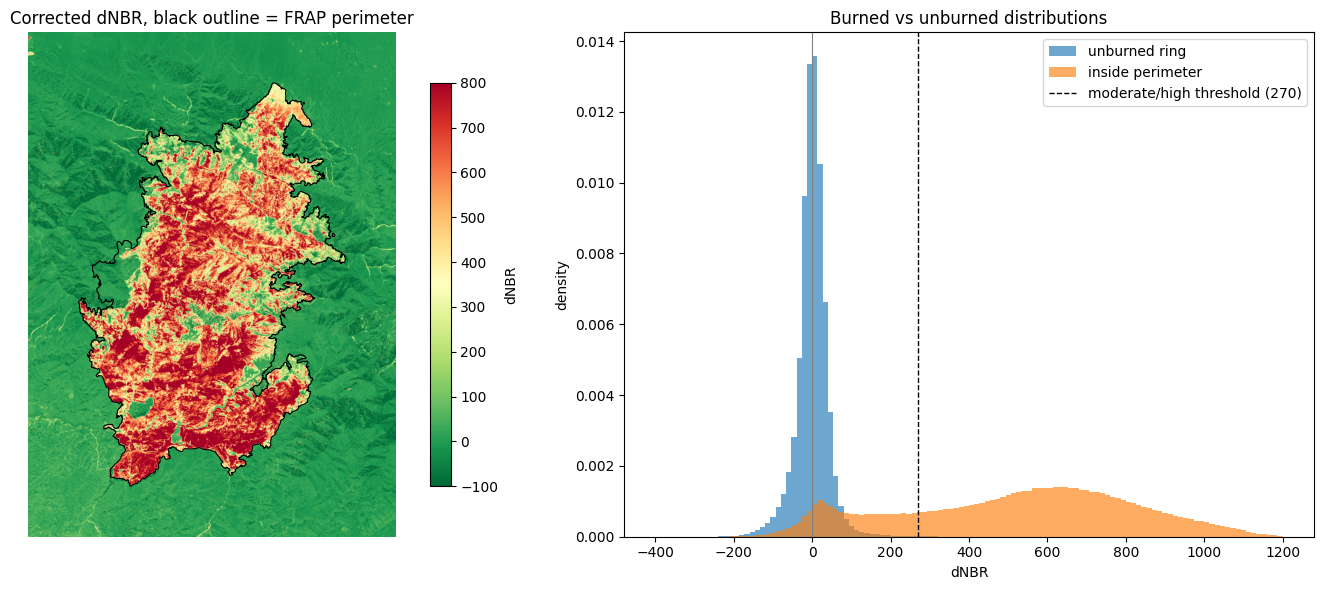

In [ ]:
# Cell 6 --- NBR, dNBR, offset correction. All math via debrisflow.severity.

import numpy as np
import matplotlib.pyplot as plt
from rasterio.features import rasterize

tr    = rasters['pre']['transform']
shape = rasters['pre']['nir'].shape

# --- Confirm the offset decision against the tested helper ---------------------
for phase, d in SCENES.items():
    print(f'needs_baseline_offset({d}) = {severity.needs_baseline_offset(d)}')

# --- NBR and uncorrected dNBR --------------------------------------------------
nbr_pre  = severity.nbr(rasters['pre']['nir'],  rasters['pre']['swir'])
nbr_post = severity.nbr(rasters['post']['nir'], rasters['post']['swir'])
dnbr_raw = severity.dnbr(nbr_pre, nbr_post)          # offset defaults to 0.0

# --- Masks ---------------------------------------------------------------------
perim_geom = perimeter.to_crs(TARGET_CRS).geometry.iloc[0]

def rast(geom):
    return rasterize([(geom, 1)], out_shape=shape, transform=tr,
                     fill=0, dtype='uint8').astype(bool)

burn_mask = rast(perim_geom)
ring_geom = perim_geom.buffer(3000).difference(perim_geom.buffer(500))
ring_mask = rast(ring_geom)

GOOD_SCL = [4, 5]        # 4 = vegetation, 5 = not-vegetated / bare soil
scl_ok = (np.isin(rasters['pre']['scl'],  GOOD_SCL) &
          np.isin(rasters['post']['scl'], GOOD_SCL))

bands = [rasters[p][b] for p in ('pre', 'post') for b in ('nir', 'swir')]
physical = np.ones(shape, dtype=bool)
for arr in bands:
    physical &= (arr <= 1.0)
finite = np.isfinite(dnbr_raw)

unburned_mask = ring_mask & scl_ok & physical & finite

print(f'\n--- Unburned reference mask ---')
print(f'ring (geometry only)      : {ring_mask.sum():>9,} px')
print(f'  after SCL 4/5 both dates: {(ring_mask & scl_ok).sum():>9,} px')
print(f'  after reflectance <= 1  : {(ring_mask & scl_ok & physical).sum():>9,} px')
print(f'  after finite            : {unburned_mask.sum():>9,} px'
      f'  ({unburned_mask.sum()/max(ring_mask.sum(),1):.1%} of ring retained)')

bright = (~physical) & finite
print(f'\nreflectance > 1.0 pixels  : {bright.sum():,} total, '
      f'{(bright & burn_mask).sum():,} inside perimeter, '
      f'{(bright & ring_mask).sum():,} inside ring')

if unburned_mask.sum() < 10000:
    print('\nWARNING: unburned sample is small. The offset may be unstable.')

# --- Offset and correction -----------------------------------------------------
offset = severity.dnbr_offset(dnbr_raw, unburned_mask)
dnbr_corrected = severity.dnbr(nbr_pre, nbr_post, offset=offset)

print(f'\n--- Offset correction ---')
print(f'dNBR offset               : {offset:.2f}')
print(f'raw mean over ring        : {np.nanmean(dnbr_raw[unburned_mask]):.2f}')
print(f'corrected mean over ring  : {np.nanmean(dnbr_corrected[unburned_mask]):.2f}  (should be ~0)')

# --- Severity inside the burn perimeter ----------------------------------------
inside = dnbr_corrected[burn_mask & finite]
sev = severity.severity_class(dnbr_corrected)
mh  = severity.moderate_high_mask(dnbr_corrected)

print(f'\n--- Severity inside the perimeter ---')
print(f'pixels                    : {inside.size:,}')
print(f'mean dNBR                 : {np.nanmean(inside):.1f}')
print(f'median dNBR               : {np.nanmedian(inside):.1f}')
print(f'percentiles 5/25/75/95    : ' +
      ', '.join(f'{np.nanpercentile(inside, q):.0f}' for q in (5, 25, 75, 95)))
for label, val in (('unburned/low', 0), ('moderate', 1), ('high', 2)):
    n = int((sev[burn_mask] == val).sum())
    print(f'  {label:14s}          : {n:>9,} px  ({n/max(inside.size,1):6.1%})')
print(f'moderate-or-high fraction : {mh[burn_mask].mean():.1%}')

# --- Look at it ----------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
show = np.where(finite, dnbr_corrected, np.nan)
im = ax[0].imshow(show, cmap='RdYlGn_r', vmin=-100, vmax=800)
ax[0].contour(burn_mask.astype(float), levels=[0.5], colors='black', linewidths=0.8)
ax[0].set_title('Corrected dNBR, black outline = FRAP perimeter')
ax[0].axis('off')
fig.colorbar(im, ax=ax[0], shrink=0.8, label='dNBR')

ax[1].hist(dnbr_corrected[unburned_mask], bins=120, range=(-400, 1200),
           alpha=0.65, label='unburned ring', density=True)
ax[1].hist(inside, bins=120, range=(-400, 1200),
           alpha=0.65, label='inside perimeter', density=True)
ax[1].axvline(270, color='k', ls='--', lw=1, label='moderate/high threshold (270)')
ax[1].axvline(0, color='gray', lw=0.8)
ax[1].set_xlabel('dNBR'); ax[1].set_ylabel('density'); ax[1].legend()
ax[1].set_title('Burned vs unburned distributions')
plt.tight_layout(); plt.show()

### What the two plots should show

**The map.** A coherent burn scar that fills the black perimeter outline, not scattered noise. The
scar should sit *inside* the outline with reasonable agreement. Perfect agreement is not expected,
because FRAP maps the fire's outer extent while dNBR measures vegetation change, and unburned
islands inside a perimeter are real.

**The histogram is the actual test.** Two distributions should be clearly separated: the unburned
ring piled up near zero, the perimeter pixels shifted well to the right. If they overlap heavily,
either the offset is wrong or the pre/post pairing is.

Expect the unburned distribution to be centred near zero **by construction**, since that is what the
offset correction just forced. The informative part is its *width*. A tight peak means a clean
correction. A broad one means the ring is heterogeneous and the single scalar offset is doing rough
work.

**Moderate-or-high fraction.** For a September fire in steep San Gabriel chaparral, something in the
40 to 70% range is plausible. This number matters more than any other on the screen: it is one half
of the M1 terrain variable T, and T is the strongest predictor in the model.

---
## Cell 7 — Write the dNBR product

The output of Part B is one raster and one JSON file. Everything downstream, meaning terrain, soils
and basin scoring, consumes these rather than re-reading Sentinel-2.

Three bands, all on the same 20 m grid:

1. **dNBR**, offset corrected, float32
2. **Severity class**, int8, 0 unburned/low, 1 moderate, 2 high, −1 NaN
3. **Valid mask**, uint8, where both dates had usable data

The provenance JSON records scene IDs, the offset value, the size of the unburned sample and the
mask rules used to select it. That file is what makes the number defensible six months from now,
and it is the difference between a pipeline and a script that happened to run once.

In [ ]:
# Cell 7 --- write the dNBR product and its provenance

DNBR_PATH = SEV_DIR / 'bridge_2024_dnbr_20m.tif'

out_profile = {
    'driver': 'GTiff', 'height': shape[0], 'width': shape[1], 'count': 3,
    'dtype': 'float32', 'nodata': np.nan, 'crs': TARGET_CRS, 'transform': tr,
    'compress': 'deflate', 'tiled': True, 'blockxsize': 256, 'blockysize': 256,
}

with rasterio.open(DNBR_PATH, 'w', **out_profile) as dst:
    dst.write(dnbr_corrected.astype('float32'), 1)
    dst.write(sev.astype('float32'), 2)
    dst.write(finite.astype('float32'), 3)
    dst.set_band_description(1, 'dNBR_offset_corrected')
    dst.set_band_description(2, 'severity_class_0low_1mod_2high_neg1nan')
    dst.set_band_description(3, 'valid_mask')
    dst.update_tags(
        fire='Bridge Fire 2024',
        perimeter_source='CAL FIRE FRAP California_Historic_Fire_Perimeters',
        pre_scene=SCENES['pre'], post_scene=SCENES['post'],
        dnbr_offset=f'{offset:.4f}',
        moderate_high_threshold='270',
    )

print(f'Saved -> {DNBR_PATH}')

prov = dict(provenance)
prov['dnbr'] = {
    'offset': float(offset),
    'offset_units': 'scaled dNBR (x1000)',
    'unburned_sample_px': int(unburned_mask.sum()),
    'unburned_rule': {
        'ring_inner_m': 500, 'ring_outer_m': 3000,
        'scl_classes': GOOD_SCL, 'scl_both_dates': True,
        'max_reflectance': 1.0,
    },
    'ring_retained_fraction': float(unburned_mask.sum() / max(int(ring_mask.sum()), 1)),
    'moderate_high_threshold': 270,
    'perimeter_stats': {
        'pixels': int(inside.size),
        'mean_dnbr': float(np.nanmean(inside)),
        'median_dnbr': float(np.nanmedian(inside)),
        'moderate_high_fraction': float(mh[burn_mask].mean()),
    },
    'perimeter_source': 'CAL FIRE FRAP, California_Historic_Fire_Perimeters, FIRE_NAME=BRIDGE, YEAR_=2024',
    'perimeter_acres_frap': 56281.0,
}

PROV_PATH = SEV_DIR / 'provenance_dnbr.json'
with open(PROV_PATH, 'w') as f:
    json.dump(prov, f, indent=2)
print(f'Saved -> {PROV_PATH}')
print(json.dumps(prov['dnbr'], indent=2))

Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/bridge_2024_dnbr_20m.tif
Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/severity/provenance_dnbr.json
{
  "offset": -5.047532558441162,
  "offset_units": "scaled dNBR (x1000)",
  "unburned_sample_px": 484963,
  "unburned_rule": {
    "ring_inner_m": 500,
    "ring_outer_m": 3000,
    "scl_classes": [
      4,
      5
    ],
    "scl_both_dates": true,
    "max_reflectance": 1.0
  },
  "ring_retained_fraction": 0.9028614513906988,
  "moderate_high_threshold": 270,
  "perimeter_stats": {
    "pixels": 566351,
    "mean_dnbr": 516.0422973632812,
    "median_dnbr": 550.6062622070312,
    "moderate_high_fraction": 0.7651615341016437
  },
  "perimeter_source": "CAL FIRE FRAP, California_Historic_Fire_Perimeters, FIRE_NAME=BRIDGE, YEAR_=2024",
  "perimeter_acres_frap": 56281.0
}


---
# Part C — Terrain

Imagery ingest is complete. The dNBR product is on disk and nothing downstream needs the
Planetary Computer for imagery again.

Terrain produces two things the model needs:

- **Slope**, for the ≥23° half of the M1 terrain variable T
- **Basin polygons**, the units every M1 prediction is made over

Decisions, settled:

| | Decision |
|---|---|
| Source | 3DEP seamless 10 m, via Planetary Computer STAC |
| Extent | perimeter bbox + **8 km**, larger than the imagery window |
| Grid | 10 m, UTM 11N, snapped so it nests inside the 20 m severity grid |
| Conditioning | fill depressions, resolve flats, D8 |
| Basins | stream links from a flow-accumulation threshold, 0.1 km² minimum |
| Burn filter | keep any basin overlapping the perimeter, record overlap fraction |

**Why 8 km and not 3 km.** Basins that drain *into* the burn area frequently start outside it. Clip
the DEM to the imagery window and those watersheds get cut off at the edge, so their flow
accumulation is wrong, their delineation is wrong, and every statistic computed over them is wrong.
The failure is silent: truncated basins look like ordinary basins. Extra DEM is cheap, so the
routing runs on a generous extent and basins get filtered to the burn afterwards.

---
## Cell 8 — Check the terrain API

Same reasoning as cell 4. `terrain.py` already has Horn slope and pysheds delineation with tests
behind them, so this prints the real signatures rather than having me guess at them.

In [ ]:
# Cell 8 --- inspect the terrain API

import inspect, importlib
from debrisflow import terrain
importlib.reload(terrain)

print('=' * 72)
print('PUBLIC API of terrain.py')
print('=' * 72)

for name, obj in sorted(vars(terrain).items()):
    if name.startswith('_') or not callable(obj):
        continue
    if getattr(obj, '__module__', None) != terrain.__name__:
        continue
    try:
        sig = inspect.signature(obj)
    except (TypeError, ValueError):
        sig = '(signature unavailable)'
    print(f'\ndef {name}{sig}')
    doc = inspect.getdoc(obj)
    if doc:
        for line in doc.split('\n')[:14]:
            print(f'    {line}')

PUBLIC API of terrain.py

def basin_T(steep, moderate_high, basin_mask)
    The M1 terrain variable T.
    
    T = fraction of basin area that is BOTH steep AND burned at moderate/high
    severity. This is an INTERSECTION. Computing it as
    (fraction steep) * (fraction burned) is wrong whenever the steep parts and
    the burned parts are spatially correlated, which in real burn scars they
    almost always are.

def basin_area_km2(basin_mask, cellsize_m=10)
    Basin area in km2, from a pixel mask and the cell size.

def cells_for_area(area_km2, cellsize_m=10)
    Convert a target basin area in km2 to a pixel count.

def condition_dem(grid, dem)
    Fill pits and depressions and resolve flats so flow routing works.
    
    A raw DEM has small artificial sinks. Left alone, flow accumulation dead
    ends in them and your basins come out fragmented. Order matters: pits,
    then depressions, then flats.

def flow_grids(grid, conditioned_dem)
    Compute D8 flow direction and flow a

---
## Cell 9 — Fetch and mosaic the 3DEP DEM

**Source.** The `3dep-seamless` STAC collection carries both 1/3 arc-second (roughly 10 m) and
1 arc-second (roughly 30 m) items, distinguished by the `gsd` property. The query filters to
`gsd = 10`. Getting this wrong is one of the quieter ways to end up with a 30 m DEM, which per the
project's own design note erases exactly the steep pixels M1 depends on.

**Reprojection, not just mosaicking.** Unlike the Sentinel-2 granules, 3DEP tiles are in geographic
coordinates (NAD83), not UTM. Degrees are useless for slope: a degree of longitude is a different
number of metres than a degree of latitude, and both change with latitude. So each tile is wrapped
in a `WarpedVRT` that reprojects to UTM 11N at 10 m before anything is read, using **bilinear**
resampling because elevation is a continuous surface.

**Grid alignment.** The DEM bounds are snapped to a multiple of 20 m even though the DEM itself is
10 m. That makes the 10 m terrain grid nest exactly inside the 20 m severity grid, so expanding
severity to the terrain grid later is a clean 2x2 block replication with no interpolation and no
half-pixel drift.

**Sanity checks to expect.** San Gabriel elevations should run roughly 400 m in the canyon bottoms
to about 3,000 m near Mount Baldy. Nodata inside the burn area should be zero: a hole in the DEM
would break flow routing straight through it.

DEM grid   : EPSG:32611, 10 m
Bounds     : (np.float64(418600.0), np.float64(3776340.0), np.float64(451140.0), np.float64(3817240.0))
Size       : 3254 x 4090 px
Severity grid nests: True

3DEP items found: 1
  n35w118-13  gsd=10

DEM shape      : (4090, 3254)
Elevation range: 196.0 to 3067.9 m
NaN cells      : 0 (0.0000%)
NaN inside burn: 0  (good)

Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/terrain/bridge_2024_dem_10m.tif


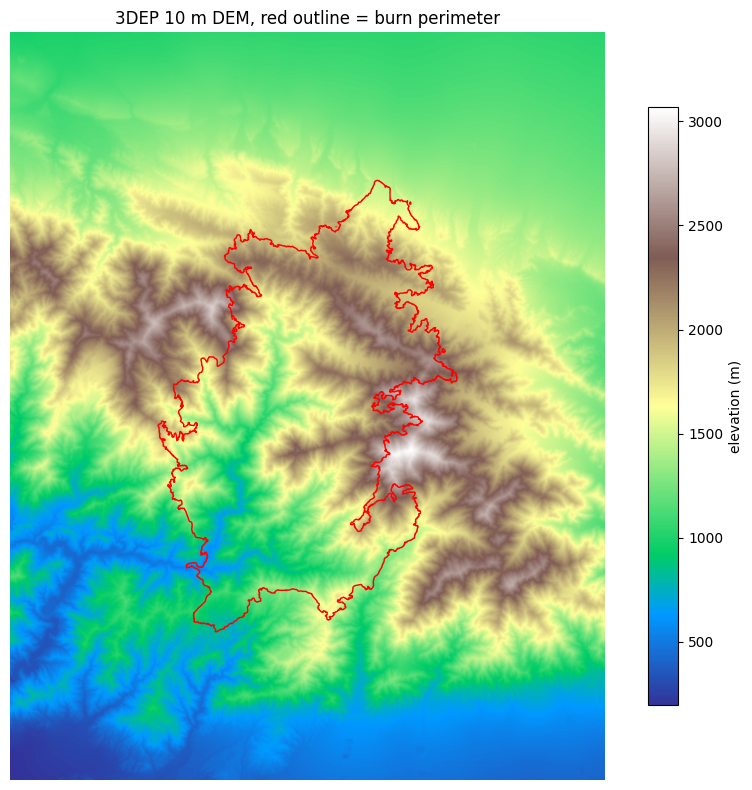

In [ ]:
# Cell 9 --- fetch, reproject and mosaic the 3DEP 10 m DEM

import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.warp import transform_bounds, calculate_default_transform

DEM_BUFFER_M = 8000
DEM_RES = 10

# --- Target grid: snapped to 20 m so the 10 m grid nests inside the severity grid
b = transform_bounds('EPSG:4326', TARGET_CRS, *perimeter.total_bounds)
dxmin = np.floor((b[0] - DEM_BUFFER_M) / 20) * 20
dymin = np.floor((b[1] - DEM_BUFFER_M) / 20) * 20
dxmax = np.ceil((b[2] + DEM_BUFFER_M) / 20) * 20
dymax = np.ceil((b[3] + DEM_BUFFER_M) / 20) * 20
DEM_BOUNDS = (dxmin, dymin, dxmax, dymax)

print(f'DEM grid   : {TARGET_CRS}, {DEM_RES} m')
print(f'Bounds     : {DEM_BOUNDS}')
print(f'Size       : {int((dxmax-dxmin)/DEM_RES)} x {int((dymax-dymin)/DEM_RES)} px')
print(f'Severity grid nests: '
      f'{(dxmin % 20 == 0) and (dymin % 20 == 0) and (xmin % 20 == 0) and (ymin % 20 == 0)}\n')

# --- STAC query, filtered to the 10 m product ---------------------------------
dem_aoi = gpd.GeoSeries([shp_box(*DEM_BOUNDS)], crs=TARGET_CRS) \
            .to_crs('EPSG:4326').iloc[0]

dem_items = list(catalog.search(
    collections=['3dep-seamless'],
    intersects=json.loads(gpd.GeoSeries([dem_aoi], crs='EPSG:4326').to_json())
                   ['features'][0]['geometry'],
    query={'gsd': {'eq': DEM_RES}},
).items())

print(f'3DEP items found: {len(dem_items)}')
for it in dem_items:
    print(f'  {it.id}  gsd={it.properties.get("gsd")}')
if not dem_items:
    raise RuntimeError('No 10 m 3DEP items returned. Check the gsd filter.')

# --- Reproject each tile on the fly, then mosaic -------------------------------
vrt_opts = {
    'crs': TARGET_CRS,
    'resampling': Resampling.bilinear,
}

srcs, vrts = [], []
try:
    for it in dem_items:
        src = rasterio.open(it.assets['data'].href)
        srcs.append(src)
        vrts.append(WarpedVRT(src, **vrt_opts))
    dem, dem_transform = merge(vrts, bounds=DEM_BOUNDS, res=(DEM_RES, DEM_RES),
                               resampling=Resampling.bilinear)
finally:
    for v in vrts:
        v.close()
    for s in srcs:
        s.close()

dem = dem[0].astype('float32')
# 3DEP uses a large negative sentinel for nodata.
dem[dem < -1000] = np.nan

print(f'\nDEM shape      : {dem.shape}')
print(f'Elevation range: {np.nanmin(dem):.1f} to {np.nanmax(dem):.1f} m')
print(f'NaN cells      : {np.isnan(dem).sum():,} ({np.isnan(dem).mean():.4%})')

# --- Nodata inside the burn area would break routing ---------------------------
from rasterio.features import rasterize as _rz
burn_dem = _rz([(perim_geom, 1)], out_shape=dem.shape, transform=dem_transform,
               fill=0, dtype='uint8').astype(bool)
holes = int(np.isnan(dem)[burn_dem].sum())
print(f'NaN inside burn: {holes:,}' + ('  <-- PROBLEM' if holes else '  (good)'))

# --- Save ----------------------------------------------------------------------
TER_DIR = FIRE_DIR / 'terrain'
DEM_PATH = TER_DIR / 'bridge_2024_dem_10m.tif'
dem_profile = {
    'driver': 'GTiff', 'height': dem.shape[0], 'width': dem.shape[1], 'count': 1,
    'dtype': 'float32', 'nodata': np.nan, 'crs': TARGET_CRS,
    'transform': dem_transform, 'compress': 'deflate', 'tiled': True,
}
with rasterio.open(DEM_PATH, 'w', **dem_profile) as dst:
    dst.write(dem, 1)
    dst.set_band_description(1, 'elevation_m_3dep_10m')
    dst.update_tags(source='USGS 3DEP seamless 1/3 arc-second via Planetary Computer',
                    buffer_m=str(DEM_BUFFER_M))
print(f'\nSaved -> {DEM_PATH}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(dem, cmap='terrain')
ax.contour(burn_dem.astype(float), levels=[0.5], colors='red', linewidths=1.0)
ax.set_title('3DEP 10 m DEM, red outline = burn perimeter')
ax.axis('off')
fig.colorbar(im, ax=ax, shrink=0.8, label='elevation (m)')
plt.tight_layout(); plt.show()

### Checks on the DEM

**Elevation range.** Roughly 400 m to 3,000 m for this extent. A range starting near zero means the
nodata sentinel was not caught. A maximum around 3,068 m means Mount Baldy is inside the window,
which is a good sign the 8 km buffer is doing its job.

**No NaN inside the burn perimeter.** A hole in the DEM inside the burn area would break flow
routing through it and silently fragment basins. This must print zero.

**The plot.** Look for tile seams, meaning straight lines where elevation jumps. 3DEP is a seamless
product so there should be none, but the mosaic is worth confirming visually the same way the
Sentinel-2 one was.

**Then stop.** Send the terrain API dump from cell 8 and these DEM diagnostics, and the next cells
run conditioning, Horn slope and basin delineation through your tested `terrain` functions.

---
## Cell 10 — Conditioning, slope and flow accumulation

Everything computed here comes from `terrain.py`. The notebook loads the raster and hands arrays
across; `condition_dem`, `flow_grids`, `slope_degrees` and `steep_mask` do the work.

**Slope comes from the RAW DEM, not the conditioned one.** This is the trap in this cell and it is
easy to get backwards. Conditioning deliberately alters elevations: it raises pits to their outlet
and imposes an artificial gradient across flats. Those edits are correct for routing and wrong for
measurement. Computing slope on the conditioned surface would report gradients that were invented
by the fill algorithm, flattening real terrain around former pits and inventing gentle slopes across
resolved flats. Since M1 thresholds slope at 23°, that contaminates the strongest predictor in the
model.

So: **raw DEM for slope, conditioned DEM for routing.** They are two different products from the
same source and they are not interchangeable.

**Cell size is 10 m and must be passed explicitly.** `slope_degrees` defaults to 10 but takes it as
an argument for a reason. The docstring is explicit that a geographic CRS breaks this function
entirely, which is exactly why cell 9 reprojected to UTM before saving.

**Accumulation is in upstream pixel counts.** At 10 m, one pixel is 100 m², so 10,000 pixels is
1 km². `cells_for_area` does that conversion, and using it rather than doing the arithmetic by hand
is how the units stay right.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.0 MB/s eta 0:00:00
pysheds grid   : (4090, 3254), crs set: True

Conditioning (pits -> depressions -> flats)...
  cells altered : 105,701 (0.794%)
  max raise     : 74.687 m

D8 flow direction and accumulation...
  max accumulation: 3,277,504 cells (327.8 km2)

Horn slope from the RAW DEM...
  slope range   : 0.0 to 74.3 degrees
  mean slope    : 22.5 degrees
  NaN (edges)   : 14,684
  steep >= 23   : 7,228,485 px (54.4% of valid)
  steep in burn : 83.0% of the burn area

M1 calibration range in cells: 1,000 to 80,000
cells above 0.1 km2 threshold: 304,426


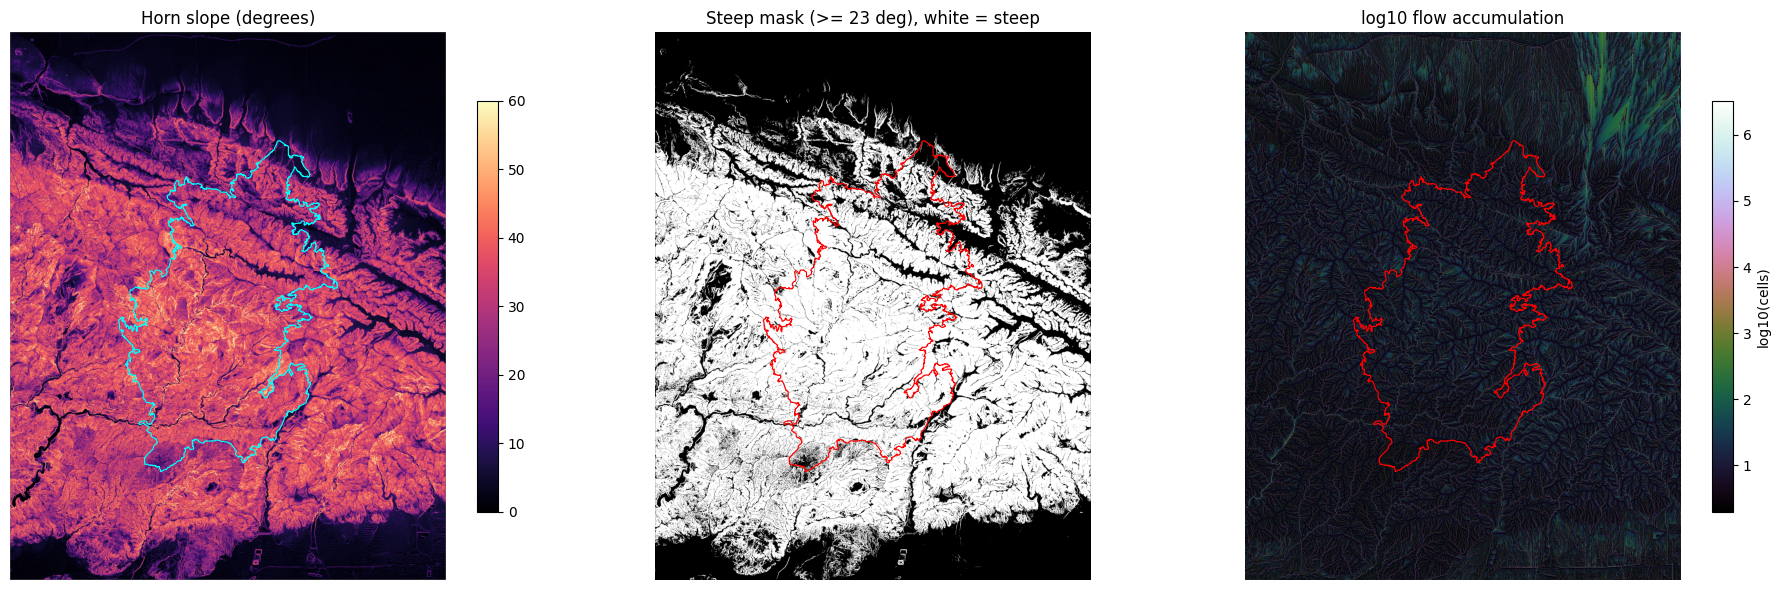

In [ ]:
# Cell 10 --- condition, route, and measure slope

!pip install -q pysheds

import numpy as np
import matplotlib.pyplot as plt
from pysheds.grid import Grid

from debrisflow import terrain
importlib.reload(terrain)

# --- Load the DEM into pysheds -------------------------------------------------
grid = Grid.from_raster(str(DEM_PATH))
dem_raster = grid.read_raster(str(DEM_PATH))
print(f'pysheds grid   : {grid.shape}, crs set: {grid.crs is not None}')

# --- Routing surface: conditioned ---------------------------------------------
print('\nConditioning (pits -> depressions -> flats)...')
conditioned = terrain.condition_dem(grid, dem_raster)
changed = np.asarray(conditioned) - np.asarray(dem_raster)
n_changed = int((np.abs(changed) > 1e-6).sum())
print(f'  cells altered : {n_changed:,} ({n_changed/changed.size:.3%})')
print(f'  max raise     : {np.nanmax(changed):.3f} m')

print('\nD8 flow direction and accumulation...')
fdir, acc = terrain.flow_grids(grid, conditioned)
acc_arr = np.asarray(acc)
print(f'  max accumulation: {acc_arr.max():,.0f} cells '
      f'({acc_arr.max() * 100 / 1e6:,.1f} km2)')

# --- Measurement surface: RAW dem ---------------------------------------------
# Slope must NOT come from the conditioned surface. See the note above.
print('\nHorn slope from the RAW DEM...')
slope = terrain.slope_degrees(dem, cellsize_m=DEM_RES)
steep = terrain.steep_mask(slope, threshold=23.0)

valid_slope = np.isfinite(slope)
print(f'  slope range   : {np.nanmin(slope):.1f} to {np.nanmax(slope):.1f} degrees')
print(f'  mean slope    : {np.nanmean(slope):.1f} degrees')
print(f'  NaN (edges)   : {(~valid_slope).sum():,}')
print(f'  steep >= 23   : {steep.sum():,} px ({steep[valid_slope].mean():.1%} of valid)')
print(f'  steep in burn : {steep[burn_dem].mean():.1%} of the burn area')

# --- Sanity: does accumulation trace a real drainage network? ------------------
min_cells = terrain.cells_for_area(0.1, cellsize_m=DEM_RES)
max_cells = terrain.cells_for_area(8.0, cellsize_m=DEM_RES)
print(f'\nM1 calibration range in cells: {min_cells:,.0f} to {max_cells:,.0f}')
print(f'cells above 0.1 km2 threshold: {(acc_arr >= min_cells).sum():,}')

fig, ax = plt.subplots(1, 3, figsize=(19, 6))

im0 = ax[0].imshow(slope, cmap='magma', vmin=0, vmax=60)
ax[0].contour(burn_dem.astype(float), levels=[0.5], colors='cyan', linewidths=0.8)
ax[0].set_title('Horn slope (degrees)'); ax[0].axis('off')
fig.colorbar(im0, ax=ax[0], shrink=0.75)

ax[1].imshow(steep, cmap='gray')
ax[1].contour(burn_dem.astype(float), levels=[0.5], colors='red', linewidths=0.8)
ax[1].set_title('Steep mask (>= 23 deg), white = steep'); ax[1].axis('off')

im2 = ax[2].imshow(np.log10(acc_arr + 1), cmap='cubehelix')
ax[2].contour(burn_dem.astype(float), levels=[0.5], colors='red', linewidths=0.8)
ax[2].set_title('log10 flow accumulation'); ax[2].axis('off')
fig.colorbar(im2, ax=ax[2], shrink=0.75, label='log10(cells)')

plt.tight_layout(); plt.show()

### Checks on cell 10

**Cells altered by conditioning should be a small percentage.** 3DEP is a good DEM. A few tenths of
a percent is normal. Several percent would suggest the nodata handling left artefacts.

**Slope range 0 to somewhere near 70 degrees**, mean somewhere in the 20s for this terrain. The San
Gabriels are among the steepest ranges in the lower 48, so a mean slope in the mid 20s is expected
rather than alarming.

**Steep fraction inside the burn is the number to note.** Combined with the 76.5% moderate-high
severity, this sets the ceiling on T. Remember T is the intersection of the two, so it will be lower
than either, and how much lower depends on whether the steep ground and the burned ground are the
same ground.

**The accumulation panel is the real test of conditioning.** It should show a branching, connected
drainage network that looks like canyons, with bright lines running continuously downhill. If it
shows short disconnected fragments that stop partway down a slope, conditioning failed and the
basins built on it will be wrong.

---
## Cell 11 — Delineate basins

Uses `debrisflow.basins`, which is new. Push `src/debrisflow/basins.py` and
`tests/test_basins.py` to the repo before running this, and re-run cell 8 so the clone picks them up.

**Outlets are restricted to the burn perimeter plus 2 km; basins are not.** The `region_mask`
controls where a basin may *start*, not how far upstream it may reach. So a canyon whose outlet sits
just outside the fire still gets delineated, and it still collects its full upstream area from the
8 km DEM. This is why the DEM buffer is larger than everything else.

**Basins are kept regardless of how little they overlap the burn.** Overlap fraction is recorded as
an attribute. A basin that is 5% burned should still be scored, and M1's own output is a better
judge of whether it is dangerous than an arbitrary cutoff would be.

Outlet region: 4,117,561 cells (412 km2)
Delineating (one pass over the sorted grid, this takes a minute)...


  basins found : 361
  touching burn: 237

  area km2      : min 0.101, median 0.38, max 7.99
  extrapolations: 0 of 237 outside 0.1-8 km2
  fully burned  : 163
  >50% burned   : 194
  total area    : 305 km2

Polygonised: 237 basin polygons
Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/terrain/bridge_2024_basins.geojson
Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/terrain/bridge_2024_basin_labels_10m.tif


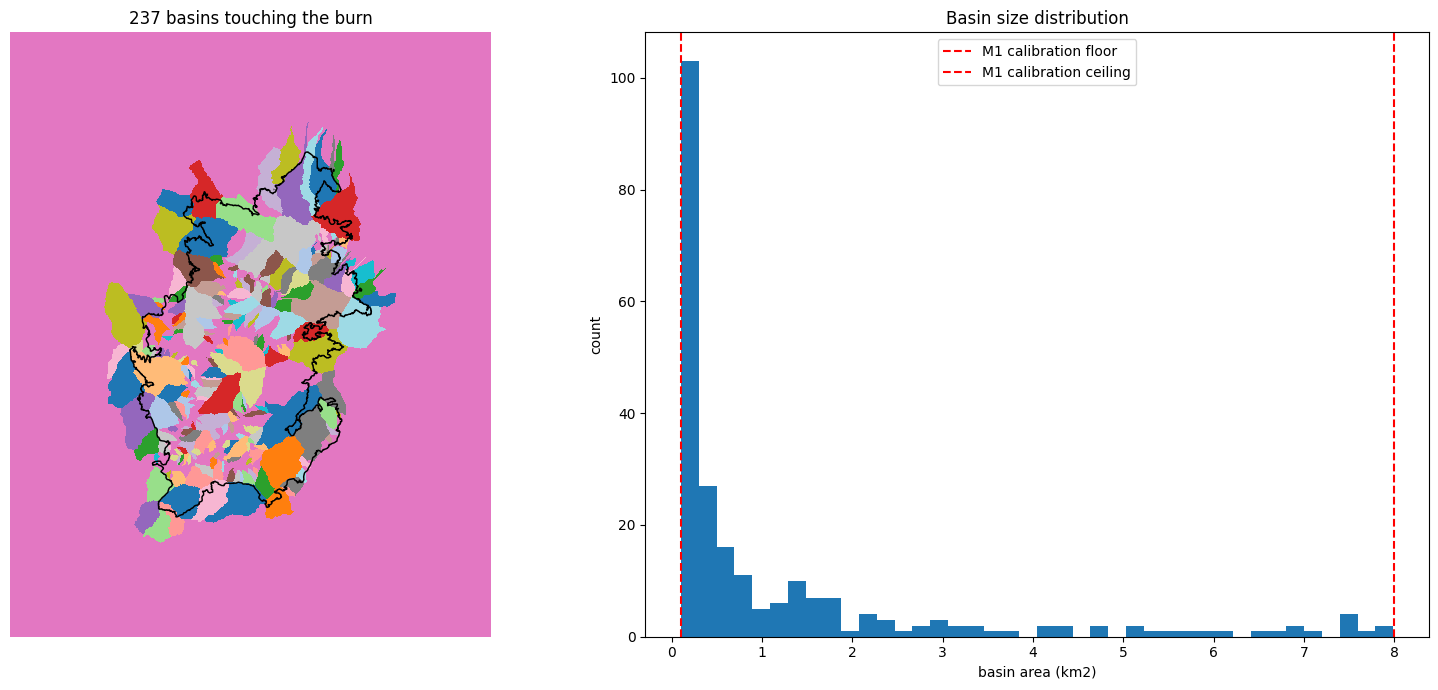

In [ ]:
# Cell 11 --- delineate non-overlapping basins

import numpy as np
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape as shp_shape

from debrisflow import basins as basins_mod
importlib.reload(basins_mod)

OUTLET_BUFFER_M = 2000

region = features.rasterize(
    [(perim_geom.buffer(OUTLET_BUFFER_M), 1)],
    out_shape=dem.shape, transform=dem_transform, fill=0, dtype='uint8').astype(bool)
print(f'Outlet region: {region.sum():,} cells '
      f'({region.sum() * 100 / 1e6:,.0f} km2)')

fdir_arr = np.asarray(fdir)
acc_arr = np.asarray(acc)

print('Delineating (one pass over the sorted grid, this takes a minute)...')
labels, records = basins_mod.delineate(
    fdir_arr, acc_arr,
    min_cells=int(min_cells), max_cells=int(max_cells),
    region_mask=region)
print(f'  basins found : {len(records):,}')

attrs = basins_mod.basin_attributes(labels, records, burn_dem, cellsize_m=DEM_RES)
burned = [a for a in attrs if a['overlap_fraction'] > 0]
print(f'  touching burn: {len(burned):,}')

areas = np.array([a['area_km2'] for a in burned])
overlaps = np.array([a['overlap_fraction'] for a in burned])
n_extrap = sum(not a['in_calibration_range'] for a in burned)
print(f'\n  area km2      : min {areas.min():.3f}, median {np.median(areas):.2f}, '
      f'max {areas.max():.2f}')
print(f'  extrapolations: {n_extrap:,} of {len(burned):,} outside 0.1-8 km2')
print(f'  fully burned  : {(overlaps > 0.99).sum():,}')
print(f'  >50% burned   : {(overlaps > 0.5).sum():,}')
print(f'  total area    : {areas.sum():,.0f} km2')

# --- Polygonise ---------------------------------------------------------------
keep = {a['id'] for a in burned}
by_id = {a['id']: a for a in burned}
geoms, ids = [], []
for geom, val in features.shapes(labels, mask=labels > 0, transform=dem_transform):
    v = int(val)
    if v in keep:
        geoms.append(shp_shape(geom))
        ids.append(v)

gdf = gpd.GeoDataFrame(
    [{k: v for k, v in by_id[i].items() if k != 'geometry'} for i in ids],
    geometry=geoms, crs=TARGET_CRS)
gdf = gdf.dissolve(by='id', as_index=False, aggfunc='first')
print(f'\nPolygonised: {len(gdf)} basin polygons')

BASIN_PATH = TER_DIR / 'bridge_2024_basins.geojson'
gdf.to_file(BASIN_PATH, driver='GeoJSON')
print(f'Saved -> {BASIN_PATH}')

LABEL_PATH = TER_DIR / 'bridge_2024_basin_labels_10m.tif'
lab_profile = dict(dem_profile, dtype='int32', nodata=0, count=1)
with rasterio.open(LABEL_PATH, 'w', **lab_profile) as dst:
    dst.write(np.where(np.isin(labels, list(keep)), labels, 0).astype('int32'), 1)
    dst.set_band_description(1, 'basin_id')
print(f'Saved -> {LABEL_PATH}')

# --- Look at it ---------------------------------------------------------------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
shown = np.where(np.isin(labels, list(keep)), labels, 0).astype(float)
shown[shown == 0] = np.nan
rng = np.random.default_rng(1)
ax[0].imshow(rng.permutation(int(labels.max()) + 2)[np.nan_to_num(shown).astype(int)],
             cmap='tab20', interpolation='nearest')
ax[0].contour(burn_dem.astype(float), levels=[0.5], colors='black', linewidths=1.0)
ax[0].set_title(f'{len(burned)} basins touching the burn'); ax[0].axis('off')

ax[1].hist(areas, bins=40)
ax[1].axvline(0.1, color='r', ls='--', label='M1 calibration floor')
ax[1].axvline(8.0, color='r', ls='--', label='M1 calibration ceiling')
ax[1].set_xlabel('basin area (km2)'); ax[1].set_ylabel('count'); ax[1].legend()
ax[1].set_title('Basin size distribution')
plt.tight_layout(); plt.show()

### Checks on cell 11

**Basin count.** Somewhere in the low hundreds for a 227 km2 fire at this basin scale. Thousands
would mean the accumulation threshold is too low; a dozen would mean it is too high.

**Look for slivers.** Very small basins hugging the edge of the outlet region are an artefact of
where the region mask was cut, not real drainages. A handful is normal. Many means the 2 km buffer
is clipping through terrain it should not.

**The map should look like a jigsaw of canyon-shaped pieces**, each running from ridge to valley,
with no piece crossing a ridgeline. Basins that look like rectangles or that straddle two canyons
mean the flow direction encoding is wrong, which the `dirmap` test in `test_basins.py` is written to
catch before it gets this far.

**Unassigned gaps are expected.** Trunk drainages with more than 8 km2 of contributing area cannot
be outlets at this scale, so the valley floors stay unlabelled. That is correct behaviour, not a
hole in the delineation.

---
# Part D — Basin variables

## Cell 12 — Align severity to the terrain grid, then compute T and F

Severity is on the 20 m grid, terrain is on the 10 m grid, and the basins are defined on the terrain
grid. Before T and F can be computed, severity has to move to 10 m.

**The move is a 2x2 block expansion, not an interpolation.** Cell 9 snapped the DEM bounds to a
multiple of 20 precisely so this would work: each 20 m severity cell covers exactly four 10 m
terrain cells, with no half-pixel offset. So each value is replicated into its four cells. Nothing
is invented, which is the whole reason for computing severity at 20 m in the first place.

**Two coverage problems get measured before anything is computed.**

*Severity extent.* The dNBR raster covers the perimeter + 3 km. Basins can reach 8 km out. Where a
basin extends past the severity raster, dNBR is NaN, `moderate_high_mask` returns False, and T is
computed as though that ground were unburned. That is a silent downward bias on the model's
strongest predictor, so this cell reports per-basin severity coverage and refuses to hide it.

*Basin coverage of the burn.* Trunk canyons above 8 km2 cannot be outlets, so valley floors are
unassigned. Those are exactly the places debris flows travel through. This cell reports what
fraction of the burn area actually sits inside a basin.

**Performance note.** Looping 237 basin masks over a 13 million cell array would be slow, so each
basin is sliced to its own bounding box first with `scipy.ndimage.find_objects`. The tested
functions still do all the arithmetic; they just see a smaller window.

severity origin offset in DEM cells: row 500.0, col 500.0
severity expanded to (4090, 3254), valid over 52.3% of the DEM extent

burn area inside some basin : 87.6%
burn area unassigned        : 12.4%   (trunk canyons above 8 km2)

--- Severity coverage per basin ---
fully covered (>= 0.999)   : 237 of 237
below 0.99                 : 0
below 0.90                 : 0
worst                      : 1.000

>>> Localised. Flag these basins rather than re-reading imagery.

--- T (steep AND moderate/high severity) ---
count    237.000
mean       0.589
std        0.364
min        0.000
25%        0.214
50%        0.779
75%        0.904
max        0.990

--- F (mean dNBR / 1000) ---
count    237.000
mean       0.463
std        0.297
min       -0.060
25%        0.193
50%        0.553
75%        0.677
max        1.022

Saved -> /content/drive/MyDrive/postfire-debris-flow/bridge_2024/terrain/bridge_2024_basins_TF.geojson


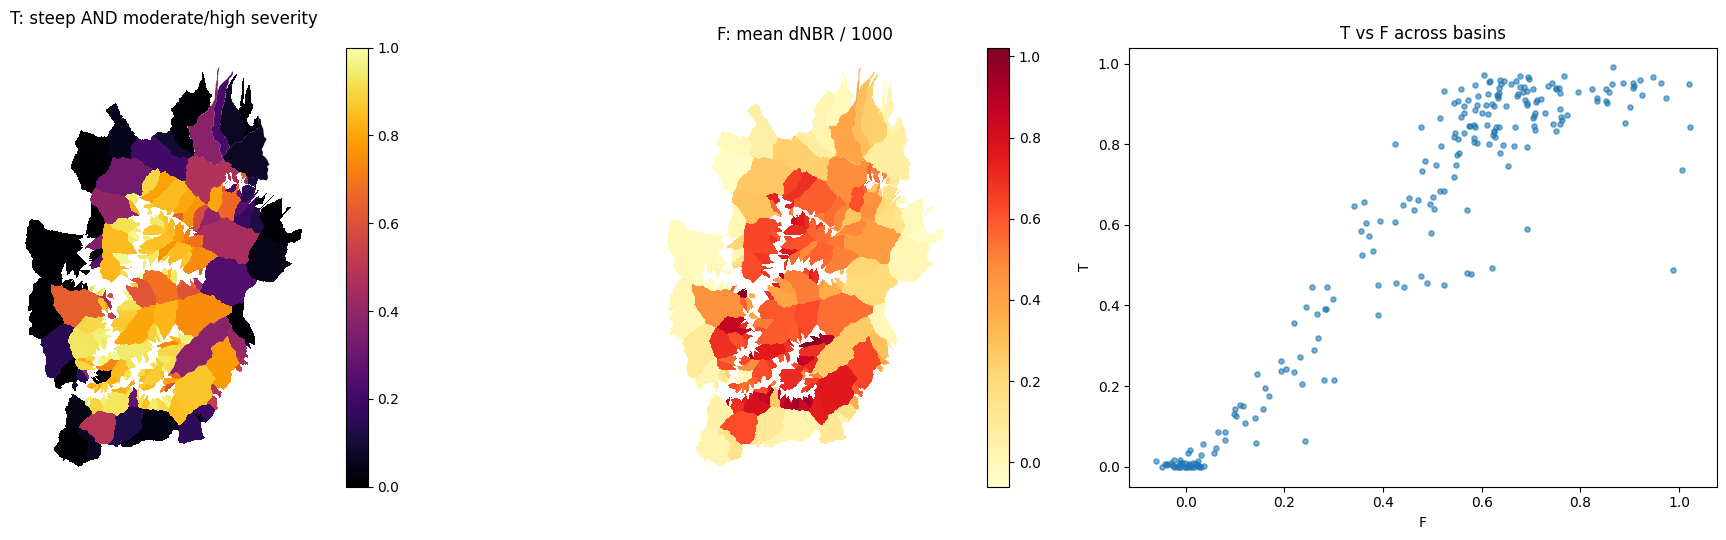

In [ ]:
# Cell 12 --- expand severity to 10 m, measure coverage, compute T and F

import numpy as np
from scipy import ndimage

# --- Confirm the grids nest, then expand ---------------------------------------
col_off = (tr.c - dem_transform.c) / DEM_RES
row_off = (dem_transform.f - tr.f) / DEM_RES
print(f'severity origin offset in DEM cells: row {row_off}, col {col_off}')
assert float(col_off).is_integer() and float(row_off).is_integer(), \
    'grids do not nest; severity cannot be block-expanded'
row_off, col_off = int(row_off), int(col_off)

def expand_to_dem(arr20, fill=np.nan):
    big = np.repeat(np.repeat(arr20, 2, axis=0), 2, axis=1)
    out = np.full(dem.shape, fill, dtype='float32')
    r1 = min(row_off + big.shape[0], dem.shape[0])
    c1 = min(col_off + big.shape[1], dem.shape[1])
    out[row_off:r1, col_off:c1] = big[:r1 - row_off, :c1 - col_off]
    return out

dnbr10 = expand_to_dem(dnbr_corrected)
sev_valid = np.isfinite(dnbr10)
mh10 = severity.moderate_high_mask(dnbr10)
print(f'severity expanded to {dnbr10.shape}, valid over '
      f'{sev_valid.mean():.1%} of the DEM extent')

# --- Finding 1: how much of the burn is inside any basin? ----------------------
in_basin = labels > 0
burn_in_basin = (burn_dem & in_basin).sum() / burn_dem.sum()
print(f'\nburn area inside some basin : {burn_in_basin:.1%}')
print(f'burn area unassigned        : {1 - burn_in_basin:.1%}'
      '   (trunk canyons above 8 km2)')

# --- Per-basin variables -------------------------------------------------------
slices = ndimage.find_objects(labels)
rows = []
for a in burned:
    i = a['id']
    sl = slices[i - 1]
    m = labels[sl] == i

    sev_cov = float(sev_valid[sl][m].mean())
    T = terrain.basin_T(steep[sl], mh10[sl], m)
    F = severity.basin_F(dnbr10[sl], m)

    rows.append({**a, 'severity_coverage': sev_cov, 'T': float(T), 'F': float(F)})

import pandas as pd
df = pd.DataFrame(rows)

# --- Finding 2: severity coverage ---------------------------------------------
print(f'\n--- Severity coverage per basin ---')
print(f'fully covered (>= 0.999)   : {(df.severity_coverage >= 0.999).sum():,} of {len(df):,}')
print(f'below 0.99                 : {(df.severity_coverage < 0.99).sum():,}')
print(f'below 0.90                 : {(df.severity_coverage < 0.90).sum():,}')
print(f'worst                      : {df.severity_coverage.min():.3f}')
if (df.severity_coverage < 0.99).sum() > 20:
    print('\n>>> Widespread. Re-run cell 5 with BUFFER_M = 8000 to match the DEM extent.')
else:
    print('\n>>> Localised. Flag these basins rather than re-reading imagery.')

print(f'\n--- T (steep AND moderate/high severity) ---')
print(df['T'].describe().round(3).to_string())
print(f'\n--- F (mean dNBR / 1000) ---')
print(df['F'].describe().round(3).to_string())

# --- Attach to the polygons and save ------------------------------------------
gdf_v = gdf.merge(df[['id', 'severity_coverage', 'T', 'F']], on='id', how='left')
VAR_PATH = TER_DIR / 'bridge_2024_basins_TF.geojson'
gdf_v.to_file(VAR_PATH, driver='GeoJSON')
print(f'\nSaved -> {VAR_PATH}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))
gdf_v.plot(column='T', ax=ax[0], legend=True, cmap='inferno', vmin=0, vmax=1)
ax[0].set_title('T: steep AND moderate/high severity'); ax[0].axis('off')
gdf_v.plot(column='F', ax=ax[1], legend=True, cmap='YlOrRd')
ax[1].set_title('F: mean dNBR / 1000'); ax[1].axis('off')
ax[2].scatter(df['F'], df['T'], s=14, alpha=0.6)
ax[2].set_xlabel('F'); ax[2].set_ylabel('T')
ax[2].set_title('T vs F across basins')
plt.tight_layout(); plt.show()

### Checks on cell 12

**The nesting assertion must pass.** If it raises, the DEM and severity grids are misaligned and
everything computed from a block expansion would be shifted by half a cell.

**Severity coverage.** The cell prints its own recommendation. Under about 20 affected basins is
worth flagging as an attribute; more than that and re-running cell 5 with an 8 km buffer is the
cleaner fix, and it costs a few minutes of re-reading rather than any new decision.

**T should be high and it should be lower than either input.** The burn is 83% steep and 76.5%
moderate-or-high. If steepness and severity were independent, T would average about 0.63. Real
terrain correlates them, so expect higher. What T cannot be is greater than either 0.83 or 0.765:
it is an intersection, and a value above both would mean the intersection logic is inverted.

**F around 0.5.** Mean dNBR inside the perimeter was 516, so F should land near 0.52 for basins
mostly inside the fire, and lower for basins that only clip it.

**The scatter plot.** T and F should rise together, since both are driven by burn severity. Basins
low on both are the ones only touching the fire's edge. A cloud with no structure would mean one of
the two is not measuring what it claims to.

---
## Cell 13 — Check the soils API

Same pattern as cells 4 and 8. `soils.py` is the one module already verified against the live
service, so this confirms the import works and pins the function names the next cell calls.

In [ ]:
# Cell 13 --- inspect the soils API
import inspect, importlib
from debrisflow import soils
importlib.reload(soils)

print('=' * 72)
print('PUBLIC API of soils.py')
print('=' * 72)

for name, obj in sorted(vars(soils).items()):
    if name.startswith('_') or not callable(obj):
        continue
    if getattr(obj, '__module__', None) != soils.__name__:
        continue
    try:
        sig = inspect.signature(obj)
    except (TypeError, ValueError):
        sig = '(signature unavailable)'
    print(f'\ndef {name}{sig}')
    doc = inspect.getdoc(obj)
    if doc:
        for line in doc.split('\n')[:14]:
            print(f'    {line}')

PUBLIC API of soils.py

def check_sda_connection()
    Smoke-test the SDA service and confirm the STATSGO area symbol works.
    
    Run this in Colab BEFORE trusting anything else in this section. If the
    schema has drifted, this fails fast with a readable error instead of
    silently returning empty soil data that becomes S = NaN downstream.

def component_to_mapunit(kf_values, comppct)
    Roll components up to one KF per map unit, weighted by comppct_r.
    
    comppct_r is the representative percent of the map unit each soil component
    occupies. It does not always sum to exactly 100, so weighted_mean
    renormalises rather than assuming it does.

def flag_low_coverage(coverage, threshold=0.5)
    Should this basin's S value be treated as unreliable?
    
    A basin that is mostly rock outcrop or water has a KF derived from a small
    minority of its area. Still worth computing, but the map should say so
    rather than presenting it with the same confidence as a fully 

---
## Cell 14 — Fetch STATSGO polygons and compute S

`soils.py` handles everything from mukeys onward. What it does not do, deliberately, is the spatial
query: it has no idea which map units cover which basins. That is this cell's job, and it is network
IO, so it belongs in the notebook.

**STATSGO geometry lives in `gsmmupolygon`, not `mupolygon`.** This distinction matters more than it
looks. SDA stores SSURGO and STATSGO together, and the convenient helper functions like
`SDA_Get_Mukey_from_intersection_with_WktWgs84` filter STATSGO *out*. Using one of those would have
returned SSURGO mukeys, which would have run without error, produced entirely plausible S values,
and silently broken design decision 4. `gsmmupolygon` is a STATSGO-only table, so no area symbol
filter is needed.

**One query, not 237.** All map unit polygons intersecting the basin extent come back in a single
request. The per-basin area weighting is then an ordinary geopandas overlay, done locally. Querying
per basin would be 237 round trips for no benefit, and the polygons are cached to Drive so a re-run
costs nothing.

**Area weights must be the INTERSECTED areas.** `mapunit_to_basin` is explicit about this in its
docstring: using a polygon's full area over-weights map units that only clip the basin edge. The
overlay produces intersected geometry, and areas are computed from that in UTM.

**Expect S to look coarse.** STATSGO map units run 1 to 10 km2 against a 0.38 km2 median basin, so
many basins will sit entirely inside one map unit and share an identical S with their neighbours.
That is not an error, it is the resolution of the dataset M1 was calibrated against, and it is
exactly what the planned SSURGO sensitivity pass exists to quantify.

Checking SDA...
[['US', 'United States']]

Query extent (WGS84): [-117.8155, 34.1828, -117.601, 34.44]
[try ] gsmmupolygon / mupolygongeo: 26 polygon(s)

Matched via: gsmmupolygon / mupolygongeo
STATSGO polygons: 26, distinct mukeys: 10

Horizon rows returned: 465
Map units with a KF  : 10 of 10
  mukey     660456 -> KF 0.2967, coverage 0.97
  mukey     660470 -> KF 0.2674, coverage 0.66
  mukey     660471 -> KF 0.2715, coverage 1.00
  mukey     660474 -> KF 0.2432, coverage 0.81
  mukey     660484 -> KF 0.2121, coverage 0.94
  mukey     660494 -> KF 0.2415, coverage 0.88
  mukey     660499 -> KF 0.2628, coverage 0.85
  mukey     660500 -> KF 0.2440, coverage 0.65

Intersection pieces: 624

--- S (area-weighted surface KF) ---
count    237.0000
mean       0.2700
std        0.0343
min        0.2417
25%        0.2440
50%        0.2588
75%        0.2630
max        0.3390

distinct S values     : 59 across 237 basins
basins flagged low cov: 0
NaN S                 : 0
failing validate_kf  

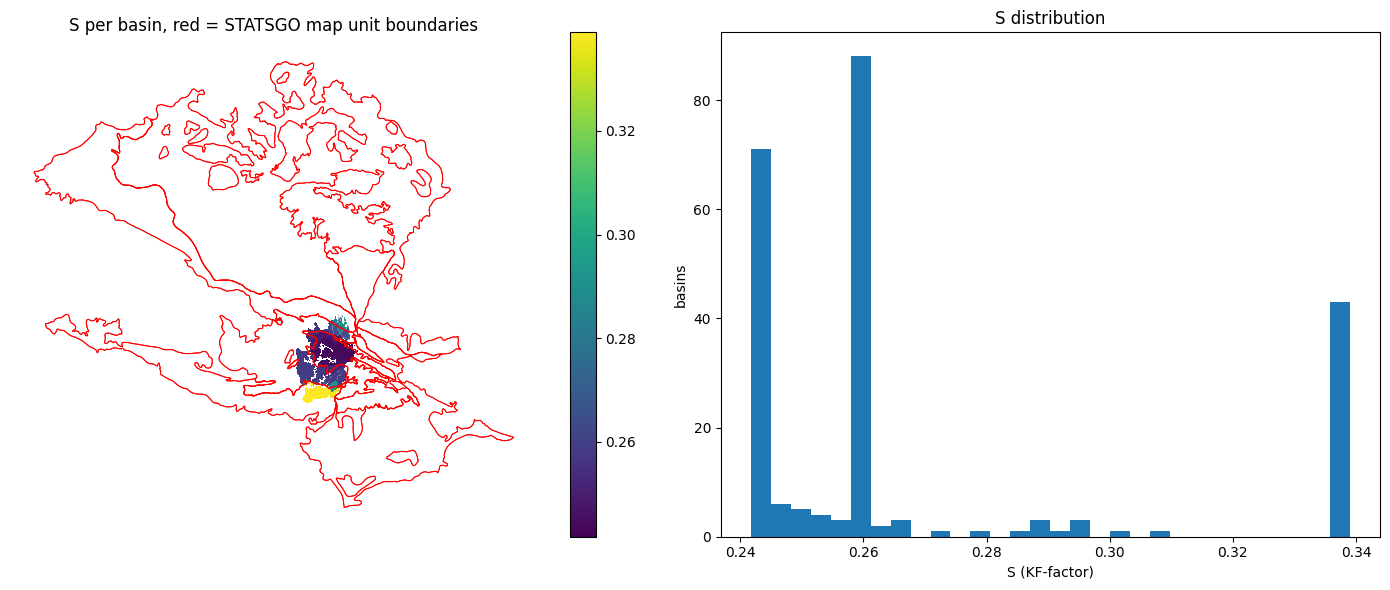

In [ ]:
# Cell 14 --- STATSGO spatial query, then S per basin

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt as shapely_wkt
from shapely.geometry import box as shp_box

# --- Fail fast if the service or schema has drifted ---------------------------
print('Checking SDA...')
print(soils.check_sda_connection())

# --- Extent to query, as WGS84 WKT --------------------------------------------
bounds4326 = gdf_v.to_crs('EPSG:4326').total_bounds
aoi_wkt = shp_box(*bounds4326).wkt
print(f'\nQuery extent (WGS84): {np.round(bounds4326, 4).tolist()}')

# gsmmupolygon is the STATSGO geometry table. Column naming has varied, so try
# the known variants and report which one answered.
SPATIAL_SQL = [
    ("gsmmupolygon / mupolygongeo",
     "SELECT G.mukey, G.mupolygongeo.STAsText() AS geom "
     "FROM gsmmupolygon AS G "
     f"WHERE G.mupolygongeo.STIntersects(geometry::STGeomFromText('{aoi_wkt}', 4326)) = 1"),
    ("gsmmupolygon / geom",
     "SELECT G.mukey, G.geom.STAsText() AS geom "
     "FROM gsmmupolygon AS G "
     f"WHERE G.geom.STIntersects(geometry::STGeomFromText('{aoi_wkt}', 4326)) = 1"),
]

rows_spatial, used_sql = None, None
for label, sql in SPATIAL_SQL:
    try:
        r = soils.sda_query(sql)
    except Exception as e:
        print(f'[skip] {label}: {type(e).__name__}: {e}')
        continue
    print(f'[try ] {label}: {len(r) if r else 0} polygon(s)')
    if r:
        rows_spatial, used_sql = r, label
        break

if not rows_spatial:
    raise RuntimeError('No STATSGO polygons returned. Inspect the SQL variants above.')

mu = gpd.GeoDataFrame(
    {'mukey': [str(r[0]) for r in rows_spatial]},
    geometry=[shapely_wkt.loads(r[1]) for r in rows_spatial],
    crs='EPSG:4326').to_crs(TARGET_CRS)
mu = mu[mu.is_valid | mu.buffer(0).is_valid].copy()
mu['geometry'] = mu.geometry.buffer(0)     # repair any self-intersections
print(f'\nMatched via: {used_sql}')
print(f'STATSGO polygons: {len(mu)}, distinct mukeys: {mu.mukey.nunique()}')

SOIL_DIR = FIRE_DIR / 'soils'
SOIL_DIR.mkdir(parents=True, exist_ok=True)
mu.to_file(SOIL_DIR / 'statsgo_mapunits.geojson', driver='GeoJSON')

# --- Tabular: surface-horizon KF for those map units --------------------------
mukeys = sorted(mu.mukey.unique())
kf_sql = soils.kf_by_mapunit_sql(mukeys, dataset='statsgo')
kf_rows = soils.sda_query(kf_sql)
print(f'\nHorizon rows returned: {len(kf_rows):,}')

kf_lookup = soils.kf_by_mapunit(kf_rows, surface_only=True)
print(f'Map units with a KF  : {len(kf_lookup)} of {len(mukeys)}')
for k in mukeys[:8]:
    v = kf_lookup.get(k)
    print(f'  mukey {k:>10} -> ' + (f'KF {v[0]:.4f}, coverage {v[1]:.2f}'
                                    if v else 'no KF (rock, water or missing)'))

# --- Area-weighted S per basin ------------------------------------------------
inter = gpd.overlay(gdf_v[['id', 'geometry']], mu, how='intersection')
inter['area_m2'] = inter.geometry.area
print(f'\nIntersection pieces: {len(inter):,}')

s_rows = []
for bid, grp in inter.groupby('id'):
    kfs, areas = [], []
    for _, r in grp.iterrows():
        v = kf_lookup.get(r['mukey'])
        kfs.append(v[0] if v else np.nan)
        areas.append(r['area_m2'])
    res = soils.mapunit_to_basin(kfs, areas)
    S, cov = res if isinstance(res, tuple) else (res, np.nan)
    s_rows.append({'id': bid, 'S': float(S), 'S_coverage': float(cov),
                   'n_mapunits': len(grp),
                   'S_low_coverage': bool(soils.flag_low_coverage(cov))
                                     if cov == cov else True})

s_df = pd.DataFrame(s_rows)
print(f'\n--- S (area-weighted surface KF) ---')
print(s_df['S'].describe().round(4).to_string())
print(f'\ndistinct S values     : {s_df.S.round(4).nunique()} across {len(s_df)} basins')
print(f'basins flagged low cov: {int(s_df.S_low_coverage.sum())}')
print(f'NaN S                 : {int(s_df.S.isna().sum())}')

bad = [v for v in s_df.S.dropna() if not soils.validate_kf(v)]
print(f'failing validate_kf   : {len(bad)}')

gdf_s = gdf_v.merge(s_df, on='id', how='left')
S_PATH = SOIL_DIR / 'bridge_2024_basins_TFS.geojson'
gdf_s.to_file(S_PATH, driver='GeoJSON')
print(f'\nSaved -> {S_PATH}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
gdf_s.plot(column='S', ax=ax[0], legend=True, cmap='viridis')
mu.boundary.plot(ax=ax[0], color='red', linewidth=0.7)
ax[0].set_title('S per basin, red = STATSGO map unit boundaries'); ax[0].axis('off')
ax[1].hist(s_df.S.dropna(), bins=30)
ax[1].set_xlabel('S (KF-factor)'); ax[1].set_ylabel('basins')
ax[1].set_title('S distribution')
plt.tight_layout(); plt.show()

### Checks on cell 14

**`check_sda_connection()` must pass first.** If the schema has drifted, everything after it returns
empty and S becomes NaN, which would flow into the model as a missing predictor rather than an
error.

**Distinct S values will be far fewer than 237.** Expect a handful. If every basin has a unique S,
something has gone wrong with the aggregation, because STATSGO simply does not vary that finely.

**The map with map unit boundaries drawn on it is the check.** Basins inside one red polygon should
share a colour. Colour changes should happen at red lines, not inside them.

**KF range 0.02 to 0.64.** `validate_kf` enforces this, and the count of failures should be zero.
For decomposed granite in the San Gabriels, expect values in the 0.15 to 0.35 band.

**Low coverage flags.** These are basins mostly on rock outcrop, which genuinely has no KF. Per
design decision 3 those components are dropped and the remainder renormalised, never zeroed. A
handful of flagged basins in steep granitic terrain is expected and correct.

### Cell 15 — Check the M1 API

Last introspection. m1.py is the tested core of the project, and likelihood() takes a rainfall convention argument with no default precisely so that the accumulation-versus-intensity error cannot happen silently. This prints the exact signature so the driver passes it correctly.

In [ ]:
# Cell 15 --- inspect the M1 API

import inspect, importlib
from debrisflow import m1
importlib.reload(m1)

print('=' * 72)
print('PUBLIC API of m1.py')
print('=' * 72)

for name, obj in sorted(vars(m1).items()):
    if name.startswith('_'):
        continue
    if not callable(obj):
        if isinstance(obj, (int, float, str, dict, tuple)):
            print(f'\n{name} = {obj!r}')      # coefficients, thresholds
        continue
    if getattr(obj, '__module__', None) != m1.__name__:
        continue
    try:
        sig = inspect.signature(obj)
    except (TypeError, ValueError):
        sig = '(signature unavailable)'
    print(f'\ndef {name}{sig}')
    doc = inspect.getdoc(obj)
    if doc:
        for line in doc.split('\n')[:16]:
            print(f'    {line}')

PUBLIC API of m1.py

def BasinVariables(T: float, F: float, S: float) -> None
    The three M1 predictors for a single drainage basin.
    
    T (terrain): fraction of upslope area that is BOTH >=23 degrees slope AND
        burned at moderate/high severity. An INTERSECTION, not two separate
        proportions. A basin can be 90% steep and 90% burned while the steep
        parts and the burned parts barely overlap; the model cares about where
        they coincide, because that is where rilling and dry ravel actually
        deliver sediment to the channel. Range 0-1.
    
    F (fire): mean dNBR of the basin, DIVIDED BY 1000. Continuous, not a class
        proportion. Typically ~0.1-0.8.
    
    S (soil): area-weighted mean soil KF-factor (erodibility). Typically
        ~0.02-0.55. Note USGS operationally uses STATSGO; SSURGO is finer but
        is a deviation from the calibration data, so say so in the writeup.

M1_PARAMETERS = {15: {'B': -3.63, 'Ct': 0.41, 'Cf': 0.67, 'Cs': 0

---
# Part E — Running the model

## Cell 16 — Score every basin

Everything the model needs now exists per basin: **T**, **F** and **S**. This cell adds **R** and
runs M1.

### Design storms

Six 15-minute intensities, 12 to 40 mm/hr, matching the set USGS publishes in operational post-fire
assessments. That choice is deliberate: it makes these numbers directly comparable to the published
Bridge Fire assessment rather than requiring a translation step.

### The rainfall convention

`likelihood()` requires the convention to be stated and has no default. The design storms below are
**intensities in mm/hr**, so `RainfallConvention.INTENSITY_MM_HR` is passed explicitly and the
tested code performs the conversion to the accumulation the model actually consumes. The notebook
does no rainfall arithmetic of its own, which is the entire point of that required argument.

### Two outputs, not one

**Probability at each design storm** answers "how likely is a debris flow if this storm hits".

**The inverted threshold** answers "how hard does it have to rain here", via `accumulation()` with
`target_p=0.5`. This is the number operational warning systems actually use, because a forecaster
can compare it directly against a predicted storm cell.

The threshold is the more useful product and the better map. A probability is conditional on a storm
that may never arrive; a threshold is a property of the basin itself.

### What to expect

Median T here is 0.779, against the 0.311 used in the synthetic test that returned 23.1 mm/hr. T is
the dominant term, so expect thresholds well below that, and expect most basins to be High at
moderate storms. That is what this fire was. Basins with T near zero, the ones only clipping the
perimeter, should come out with very high thresholds, and their presence is what shows the model
still discriminates rather than painting everything red.

Coefficients in use: {'B': -3.63, 'Ct': 0.41, 'Cf': 0.67, 'Cs': 0.7}
Model consumes     : accumulation_mm
Design storms      : [12, 16, 20, 24, 32, 40] mm/hr over 15 min

F clamped to 0 : 19 of 237 basins (min raw F was -0.0604)
  their T range: 0.018 max   <-- should be near zero; these are basins barely touching the fire

Monotonicity check passed: p rises with rainfall in every basin.

--- Probability by design storm ---
       p_12   p_16   p_20   p_24   p_32   p_40
mean  0.241  0.397  0.536  0.633  0.735  0.788
50%   0.275  0.480  0.692  0.845  0.970  0.995
min   0.043  0.050  0.059  0.069  0.095  0.129
max   0.546  0.811  0.939  0.982  0.999  1.000

--- Fraction of basins at High (p >= 0.6) ---
  12 mm/hr :   0.0%
  16 mm/hr :  24.1%
  20 mm/hr :  54.4%
  24 mm/hr :  63.7%
  32 mm/hr :  70.9%
  40 mm/hr :  75.1%

--- Rainfall threshold for P = 0.5 (mm/hr, 15 min) ---
  basins solved : 237 of 237
  unreachable   : 0  (cannot reach P=0.5 at any realistic rate)
count    237.00
mean 

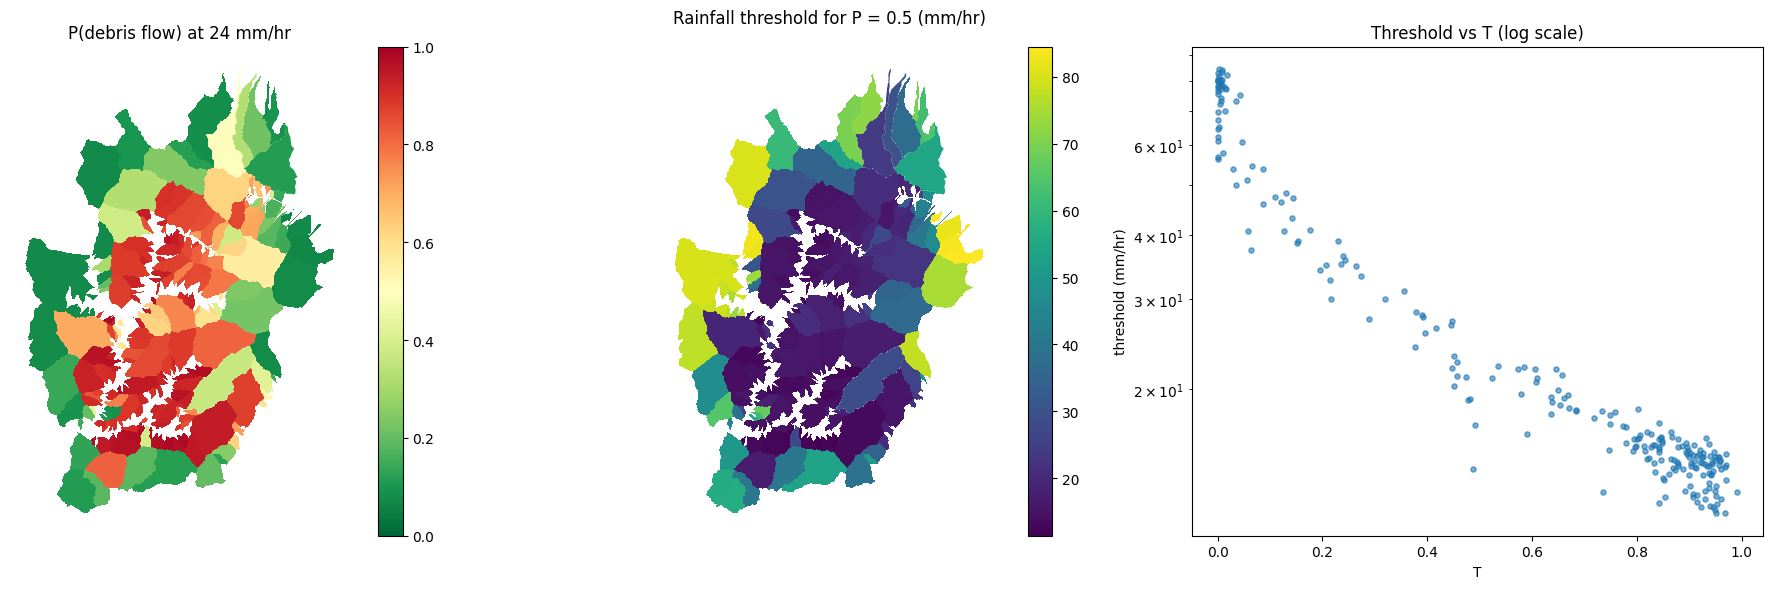

In [ ]:
# Cell 16 --- run M1 on every basin

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from debrisflow import m1
importlib.reload(m1)

# 15-minute design storm intensities, mm/hr. The set USGS publishes.
DESIGN_STORMS = [12, 16, 20, 24, 32, 40]
REFERENCE_STORM = 24
INTENSITY = m1.RainfallConvention.INTENSITY_MM_HR

print(f'Coefficients in use: {m1.M1_PARAMETERS[15]}')
print(f'Model consumes     : {m1.MODEL_CONVENTION.value}')
print(f'Design storms      : {DESIGN_STORMS} mm/hr over 15 min\n')

# --- F is clamped at zero ------------------------------------------------------
# A negative basin-mean dNBR means the basin looked slightly GREENER after the
# fire than before. For basins that only clip the perimeter that is scene noise
# around zero, not a measurement of negative burning. M1's F term is a burn
# magnitude whose floor is "no burn", and BasinVariables rejects F < 0 for
# exactly this reason. So F is clamped here, in the driver, and the raw value is
# carried alongside it so the clamp is visible in the output rather than hidden.
# The guard in m1.py is left alone: weakening tested code to accept messy input
# is the wrong direction.

scores = []
for _, row in gdf_s.iterrows():
    F_raw = float(row['F'])
    F_used = max(F_raw, 0.0)

    bv = m1.BasinVariables(T=float(row['T']), F=F_used, S=float(row['S']))

    rec = {'id': int(row['id']), 'F_raw': F_raw, 'F_used': F_used,
           'F_clamped': bool(F_raw < 0.0)}
    for r in DESIGN_STORMS:
        # Convention stated explicitly; the tested code does the conversion.
        rec[f'p_{r}'] = float(m1.likelihood(bv, r, convention=INTENSITY, duration_min=15))

    try:
        thr = float(m1.accumulation(bv, target_p=0.5, duration_min=15))
    except Exception:
        thr = np.inf          # cannot reach P=0.5 at any realistic rate
    rec['threshold_mm_hr'] = thr
    rec['hazard_at_ref'] = m1.hazard_class(rec[f'p_{REFERENCE_STORM}'])
    scores.append(rec)

sc = pd.DataFrame(scores)

n_clamped = int(sc.F_clamped.sum())
print(f'F clamped to 0 : {n_clamped} of {len(sc)} basins '
      f'(min raw F was {sc.F_raw.min():.4f})')
if n_clamped:
    print(f'  their T range: {gdf_s.set_index("id").loc[sc[sc.F_clamped].id, "T"].max():.3f} max'
          '   <-- should be near zero; these are basins barely touching the fire')

# --- Monotonicity: p must rise with rainfall for every basin -------------------
pcols = [f'p_{r}' for r in DESIGN_STORMS]
diffs = sc[pcols].diff(axis=1).iloc[:, 1:]
assert (diffs >= -1e-9).all().all(), 'probability decreased with more rainfall'
print('\nMonotonicity check passed: p rises with rainfall in every basin.\n')

print('--- Probability by design storm ---')
print(sc[pcols].describe().loc[['mean', '50%', 'min', 'max']].round(3).to_string())

print('\n--- Fraction of basins at High (p >= 0.6) ---')
for r in DESIGN_STORMS:
    print(f'  {r:>2} mm/hr : {(sc[f"p_{r}"] >= 0.6).mean():6.1%}')

print('\n--- Rainfall threshold for P = 0.5 (mm/hr, 15 min) ---')
finite = sc.threshold_mm_hr[np.isfinite(sc.threshold_mm_hr)]
print(f'  basins solved : {len(finite)} of {len(sc)}')
print(f'  unreachable   : {len(sc) - len(finite)}  (cannot reach P=0.5 at any realistic rate)')
print(finite.describe().round(2).to_string())

print(f'\n--- Hazard class at {REFERENCE_STORM} mm/hr ---')
print(sc.hazard_at_ref.value_counts().to_string())

# --- Attach and save ----------------------------------------------------------
gdf_m = gdf_s.merge(sc, on='id', how='left')
MODEL_DIR = FIRE_DIR / 'model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT = MODEL_DIR / 'bridge_2024_basins_scored.geojson'
gdf_m.drop(columns=['threshold_mm_hr']).assign(
    threshold_mm_hr=gdf_m.threshold_mm_hr.replace([np.inf, -np.inf], None)
).to_file(OUT, driver='GeoJSON')
print(f'\nSaved -> {OUT}')

# --- Maps ----------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(19, 6))

gdf_m.plot(column=f'p_{REFERENCE_STORM}', ax=ax[0], legend=True,
           cmap='RdYlGn_r', vmin=0, vmax=1)
ax[0].set_title(f'P(debris flow) at {REFERENCE_STORM} mm/hr'); ax[0].axis('off')

plot_thr = gdf_m.copy()
plot_thr['thr_plot'] = plot_thr.threshold_mm_hr.replace([np.inf, -np.inf], np.nan)
plot_thr.plot(column='thr_plot', ax=ax[1], legend=True, cmap='viridis',
              missing_kwds={'color': 'lightgrey', 'label': 'unreachable'})
ax[1].set_title('Rainfall threshold for P = 0.5 (mm/hr)'); ax[1].axis('off')

ax[2].scatter(gdf_m['T'], gdf_m.threshold_mm_hr, s=14, alpha=0.6)
ax[2].set_xlabel('T'); ax[2].set_ylabel('threshold (mm/hr)')
ax[2].set_yscale('log')
ax[2].set_title('Threshold vs T (log scale)')
plt.tight_layout(); plt.show()

### Checks on cell 16

**Thresholds should span a wide range.** Basins with T near 0.99 should need very little rain;
basins with T near zero should need a great deal, possibly more than the solver can reach. Anything
non-finite is a basin the model cannot push to P = 0.5 at any realistic intensity, which is a
meaningful answer rather than a failure.

**Monotonicity.** Probability must rise with rainfall for every basin, and a basin with higher T, F
and S must never have a higher threshold than one lower on all three. The cell asserts the first and
plots the second.

**Compare against the published USGS assessment for the Bridge Fire.** That is the next step after
this cell, and the first genuine external validation this pipeline has had. Expect the shapes to
agree and the absolute numbers to differ somewhat, since the severity input here is vegetation dNBR
rather than field-mapped soil burn severity.

---
# Part F — Cross-validation against the official USGS implementation

## Cell 17 — Compare `debrisflow.m1` against `pfdf.models.staley2017`

This is the strongest validation artifact this project can produce. `m1.py` is an independent
reimplementation of a published model. The only way to establish that it is *correct*, rather than
merely self-consistent, is to run the reference implementation on identical inputs and compare.

### What is being compared

All 237 basins at all six design storms, both directions of the model:

- **Forward**: probability given rainfall
- **Inverse**: rainfall accumulation needed to reach P = 0.5

Same T, F and S. Same coefficients. If the two agree to floating-point tolerance across 1,422
forward evaluations, the implementation is right.

### Two unit traps to be explicit about

**pfdf takes rainfall as accumulation in mm.** The design storms in this notebook are intensities
in mm/hr. Over 15 minutes those differ by a factor of 4, which is design decision 1 in this project.
The conversion is done through `m1.convert_rainfall` rather than by writing `/ 4` inline, so the
tested code owns it on both sides of the comparison.

**pfdf's `accumulation` returns mm; ours returns mm/hr.** Ours is named to match theirs but defaults
to the intensity units operational products quote. Converting one to the other before comparing is
mandatory, and getting it wrong would produce a clean 4x disagreement that looks like a modelling
error rather than a units error.

### The argument order is interleaved

The reference call is `s17.likelihood(R, B, Ct, T, Cf, F, Cs, S)`: coefficient, variable,
coefficient, variable. Transposing `Ct` and `Cf` would still run and would still produce plausible
probabilities. The parameters are unpacked from `s17.M1.parameters()` rather than typed in, so the
comparison also confirms this project's coefficients match the ones USGS ships.

### After this cell

It prints a small fixture block. That gets pasted into `tests/test_m1_pfdf.py` so the agreement is
pinned as a regression test that runs without pfdf installed, exactly like the captured SDA output
in `test_soils_sda.py`.

In [ ]:
# Cell 17 --- cross-validate against the official USGS pfdf package

# pfdf is distributed from the USGS GitLab package index, not PyPI.
!pip install -q pfdf -i https://code.usgs.gov/api/v4/groups/859/-/packages/pypi/simple

import numpy as np
import pandas as pd

import pfdf
from pfdf.models import staley2017 as s17

from debrisflow import m1
importlib.reload(m1)

print(f'pfdf version: {getattr(pfdf, "__version__", "unknown")}\n')

# --- Coefficients: read from pfdf, compare against ours -----------------------
B, Ct, Cf, Cs = s17.M1.parameters(durations=15)
print(f'pfdf   B={np.ravel(B)[0]}, Ct={np.ravel(Ct)[0]}, '
      f'Cf={np.ravel(Cf)[0]}, Cs={np.ravel(Cs)[0]}')
ours = m1.M1_PARAMETERS[15]
print(f'ours   B={ours["B"]}, Ct={ours["Ct"]}, Cf={ours["Cf"]}, Cs={ours["Cs"]}')
for k, v in zip(('B', 'Ct', 'Cf', 'Cs'), (B, Ct, Cf, Cs)):
    assert np.isclose(np.ravel(v)[0], ours[k]), f'coefficient {k} differs'
print('Coefficients match.\n')

# --- Inputs -------------------------------------------------------------------
T = gdf_m['T'].to_numpy(dtype=float)
F = gdf_m['F_used'].to_numpy(dtype=float)      # the clamped value the model saw
S = gdf_m['S'].to_numpy(dtype=float)

# pfdf wants ACCUMULATION in mm. Convert through the tested helper.
R_acc = np.array([
    m1.convert_rainfall(r,
                        frm=m1.RainfallConvention.INTENSITY_MM_HR,
                        to=m1.RainfallConvention.ACCUMULATION_MM,
                        duration_min=15)
    for r in DESIGN_STORMS], dtype=float)
print(f'design storms  : {DESIGN_STORMS} mm/hr')
print(f'as accumulation: {R_acc.tolist()} mm over 15 min\n')

# --- Forward model -------------------------------------------------------------
# Argument order is interleaved: R, B, Ct, T, Cf, F, Cs, S
p_ref = np.asarray(s17.likelihood(R_acc, B, Ct, T, Cf, F, Cs, S))
print(f'pfdf likelihood output shape: {p_ref.shape}')
p_ref = np.squeeze(p_ref)
if p_ref.shape != (len(T), len(DESIGN_STORMS)):
    p_ref = p_ref.reshape(len(T), len(DESIGN_STORMS))

p_ours = gdf_m[[f'p_{r}' for r in DESIGN_STORMS]].to_numpy(dtype=float)

diff = np.abs(p_ours - p_ref)
print(f'\n--- Forward: {diff.size:,} comparisons ---')
print(f'max abs difference : {diff.max():.3e}')
print(f'mean abs difference: {diff.mean():.3e}')
print(f'agree to 1e-9      : {(diff < 1e-9).mean():.2%}')
worst = np.unravel_index(np.argmax(diff), diff.shape)
print(f'worst case: basin index {worst[0]}, storm {DESIGN_STORMS[worst[1]]} mm/hr, '
      f'ours {p_ours[worst]:.10f} vs pfdf {p_ref[worst]:.10f}')

# --- Inverse model -------------------------------------------------------------
acc_ref = np.squeeze(np.asarray(s17.accumulation(0.5, B, Ct, T, Cf, F, Cs, S)))
acc_ref = np.ravel(acc_ref)[:len(T)] if acc_ref.ndim > 1 else acc_ref
# pfdf returns mm accumulated; ours returns mm/hr. Convert theirs to ours.
thr_ref = np.array([
    m1.convert_rainfall(a,
                        frm=m1.RainfallConvention.ACCUMULATION_MM,
                        to=m1.RainfallConvention.INTENSITY_MM_HR,
                        duration_min=15)
    for a in acc_ref], dtype=float)

thr_ours = gdf_m['threshold_mm_hr'].to_numpy(dtype=float)
ok = np.isfinite(thr_ours) & np.isfinite(thr_ref)
tdiff = np.abs(thr_ours[ok] - thr_ref[ok])
print(f'\n--- Inverse: {ok.sum():,} comparisons (mm/hr) ---')
print(f'max abs difference : {tdiff.max():.3e}')
print(f'mean abs difference: {tdiff.mean():.3e}')
print(f'relative max       : {(tdiff / thr_ref[ok]).max():.3e}')

# --- Fixture for the regression test ------------------------------------------
# Pick a spread of basins so the fixture covers the range, not just the middle.
idx = np.argsort(T)[np.linspace(0, len(T) - 1, 8).astype(int)]
print('\n' + '=' * 72)
print('PASTE THIS INTO tests/test_m1_pfdf.py')
print('=' * 72)
print('PFDF_FIXTURE = [')
for i in idx:
    ps = ', '.join(f'{v:.12f}' for v in p_ref[i])
    print(f'    dict(T={T[i]:.6f}, F={F[i]:.6f}, S={S[i]:.6f},')
    print(f'         p=[{ps}],')
    print(f'         threshold_mm_hr={thr_ref[i]:.12f}),')
print(']')
print(f'DESIGN_STORMS_MM_HR = {DESIGN_STORMS}')
print(f'PFDF_VERSION = {getattr(pfdf, "__version__", "unknown")!r}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.5/91.5 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 38.8 MB/s eta 0:00:00
pfdf version: unknown

pfdf   B=-3.63, Ct=0.41, Cf=0.67, Cs=0.7
ours   B=-3.63, Ct=0.41, Cf=0.67, Cs=0.7
Coefficients match.

design storms  : [12, 16, 20, 24, 32, 40] mm/hr
as accumulation: [3.0, 4.0, 5.0, 6.0, 8.0, 10.0] mm over 15 min

pfdf likelihood output shape: (237, 6)

--- Forward: 1,422 comparisons ---
max abs difference : 0.000e+00
mean abs difference: 0.000e+00
agree to 1e-9      : 100.00%
worst case: basin index 0, storm 12 mm/hr, ours 0.2543934331 vs pfdf 0.2543934331

--- Inverse: 237 comparisons (mm/hr) ---
max abs difference : 0.000e+00
mean abs difference: 0.000e+00
relative max       : 0.000e+00

PASTE THIS INTO 

### Checks on cell 17

**Maximum absolute difference should be around 1e-12**, which is float noise. Anything at 1e-3 or
larger means a real disagreement.

**If the difference is almost exactly a factor of 4** somewhere, that is the accumulation versus
intensity error, not a modelling difference.

**If probabilities agree but thresholds do not**, the forward model is right and the inverse solver
differs, most likely in what it does at the extremes.

**If pfdf will not install**, that is worth knowing and not worth fighting. The comparison can also
be done by hand from the published equation, and the sensitivity analysis is not blocked by it.
Report the error rather than working around it.

**Copy the fixture block** printed at the end into `tests/test_m1_pfdf.py`.

In [ ]:
# Cell 17b --- prove the comparison is capable of failing
import numpy as np
from pfdf.models import staley2017 as s17

def ref(R, b, c1, t, c2, f, c3, s):
    out = np.squeeze(np.asarray(s17.likelihood(R, b, c1, t, c2, f, c3, s)))
    return out.reshape(len(T), len(DESIGN_STORMS))

checks = {
    'baseline (should be 0)':      ref(R_acc, B, Ct, T, Cf, F, Cs, S),
    'Ct and Cf swapped':           ref(R_acc, B, Cf, T, Ct, F, Cs, S),
    'intensity passed as mm (4x)': ref(np.array(DESIGN_STORMS, float), B, Ct, T, Cf, F, Cs, S),
    'Ct perturbed by 1%':          ref(R_acc, B, Ct * 1.01, T, Cf, F, Cs, S),
    'T and F swapped':             ref(R_acc, B, Ct, F, Cf, T, Cs, S),
}
for label, arr in checks.items():
    print(f'{label:30s} max diff vs ours: {np.abs(p_ours - arr).max():.6e}')

baseline (should be 0)         max diff vs ours: 0.000000e+00
Ct and Cf swapped              max diff vs ours: 1.268120e-01
intensity passed as mm (4x)    max diff vs ours: 8.345341e-01
Ct perturbed by 1%             max diff vs ours: 3.982900e-03
T and F swapped                max diff vs ours: 1.268120e-01
